/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


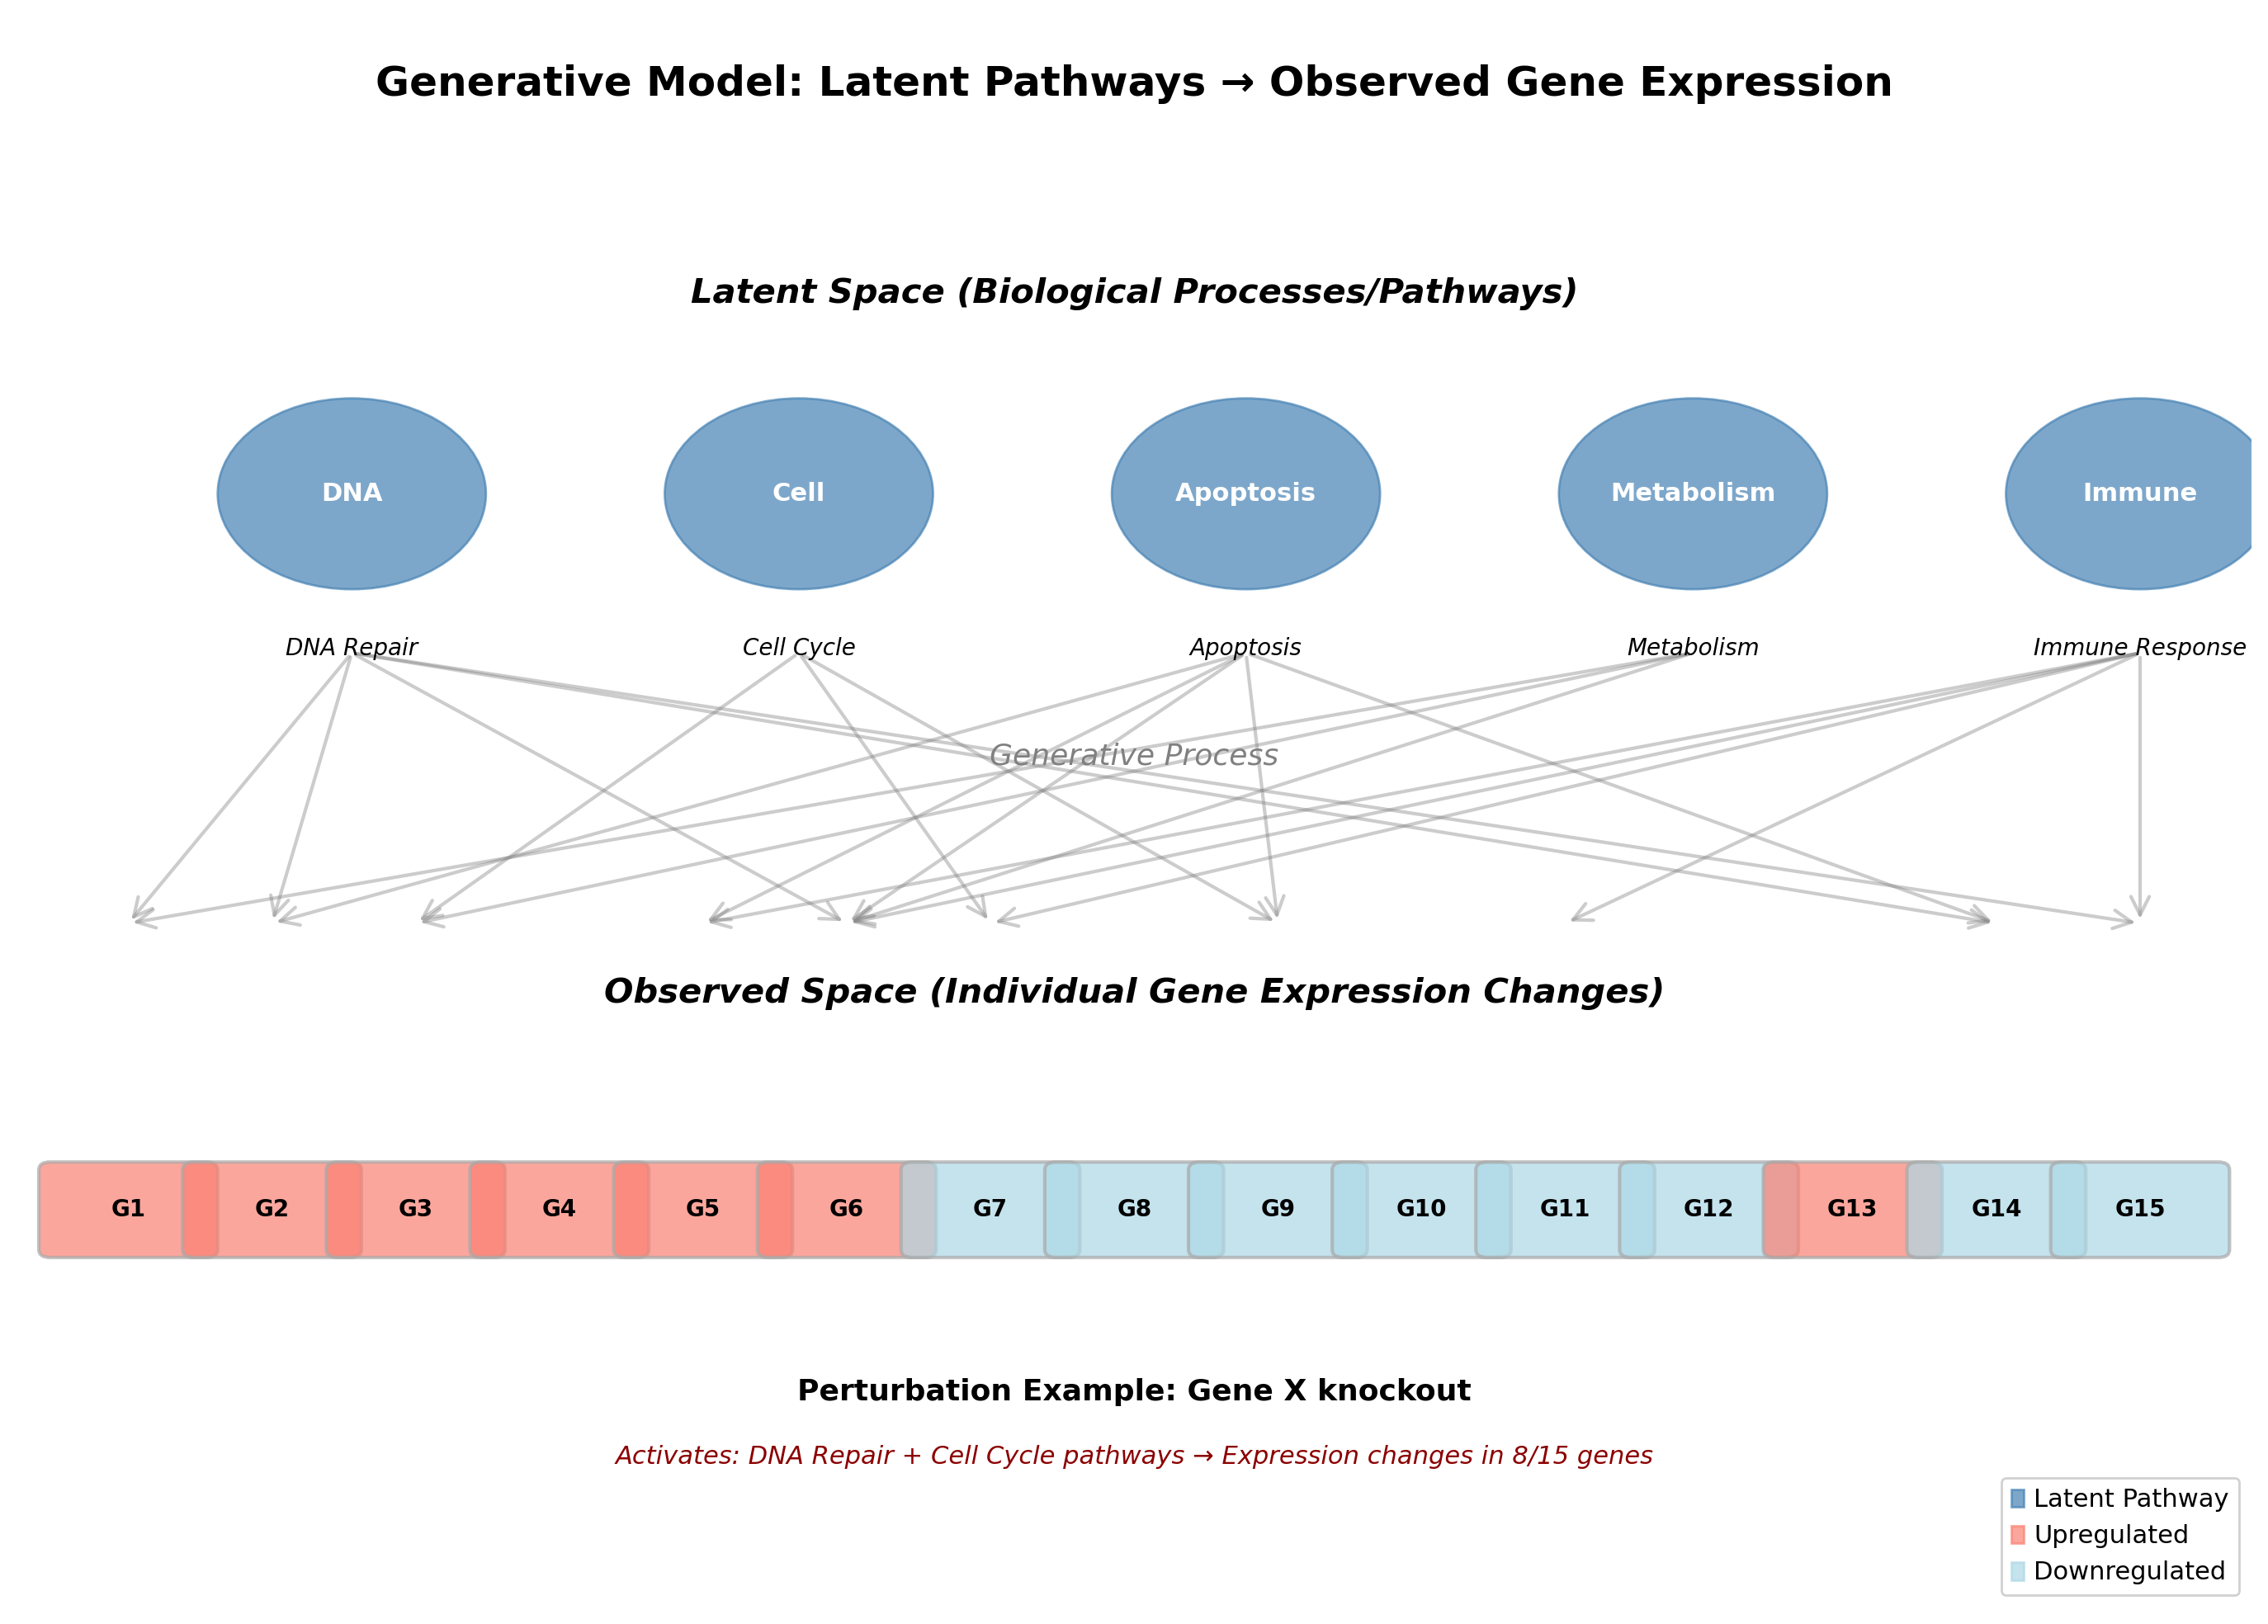

In [1]:

from libraries import *
from parameters import *
from util import *
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Generative Model: Latent Pathways → Observed Gene Expression', 
        ha='center', fontsize=18, fontweight='bold')

# ============================================================
# LATENT SPACE (top layer)
# ============================================================
latent_y = 7
latent_pathways = [
    ('DNA Repair', 1.5),
    ('Cell Cycle', 3.5),
    ('Apoptosis', 5.5),
    ('Metabolism', 7.5),
    ('Immune Response', 9.5)
]

ax.text(5, 8.2, 'Latent Space (Biological Processes/Pathways)', 
        ha='center', fontsize=15, fontweight='bold', style='italic')

for pathway, x in latent_pathways:
    circle = plt.Circle((x, latent_y), 0.6, color='steelblue', alpha=0.7, zorder=3)  # Increased from 0.4 to 0.6
    ax.add_patch(circle)
    ax.text(x, latent_y, pathway.split()[0], ha='center', va='center', 
            fontsize=11, color='white', fontweight='bold', zorder=4)  # Increased from 9 to 11
    ax.text(x, latent_y - 0.9, pathway, ha='center', va='top', 
            fontsize=10, style='italic')  # Increased from 8 to 10

# ============================================================
# ARROWS showing generative process
# ============================================================
arrow_y_start = 6.0
arrow_y_end = 4.3

# Create fan-out arrows from each latent factor to multiple genes
np.random.seed(42)
gene_positions = np.linspace(0.5, 9.5, 15)

for pathway, x_latent in latent_pathways:
    # Each pathway connects to multiple genes
    n_connections = np.random.randint(3, 6)
    target_genes = np.random.choice(gene_positions, size=n_connections, replace=False)
    
    for x_gene in target_genes:
        arrow = FancyArrowPatch(
            (x_latent, arrow_y_start), 
            (x_gene, arrow_y_end),
            arrowstyle='->', 
            mutation_scale=20,  # Increased from 15 to 20
            linewidth=1.5,  # Increased from 0.8 to 1.5
            color='gray', 
            alpha=0.4,  # Slightly increased visibility
            zorder=1
        )
        ax.add_patch(arrow)

ax.text(5, 5.3, 'Generative Process', ha='center', fontsize=13, 
        style='italic', color='gray')  # Increased from 11 to 13
# ax.text(5, 4.9, '(Latent factors activate gene programs)', ha='center', 
#         fontsize=11, color='gray')  # Increased from 9 to 11

# ============================================================
# OBSERVED SPACE (bottom layer)
# ============================================================
observed_y = 2.5

ax.text(5, 3.8, 'Observed Space (Individual Gene Expression Changes)', 
        ha='center', fontsize=15, fontweight='bold', style='italic')  # Increased from 13 to 15

# Gene boxes - BIGGER
gene_names = [f'Gene {i+1}' for i in range(15)]
box_width = 0.7  # Increased from 0.5 to 0.7
box_height = 0.5  # Increased from 0.3 to 0.5

for i, (gene, x) in enumerate(zip(gene_names, gene_positions)):
    # Random expression change (up/down)
    is_upregulated = np.random.rand() > 0.5
    color = 'salmon' if is_upregulated else 'lightblue'
    
    rect = FancyBboxPatch(
        (x - box_width/2, observed_y - box_height/2), 
        box_width, box_height,
        boxstyle="round,pad=0.05", 
        facecolor=color, 
        edgecolor='darkgray',
        alpha=0.7,
        linewidth=1.5,  # Increased from 1 to 1.5
        zorder=2
    )
    ax.add_patch(rect)
    
    ax.text(x, observed_y, f'G{i+1}', ha='center', va='center', 
            fontsize=10, fontweight='bold')  # Increased from 7 to 10

# ============================================================
# Add perturbation context
# ============================================================
ax.text(5, 1.3, 'Perturbation Example: Gene X knockout', 
        ha='center', fontsize=13, fontweight='bold')  # Increased from 11 to 13
ax.text(5, 0.9, 'Activates: DNA Repair + Cell Cycle pathways → Expression changes in 8/15 genes', 
        ha='center', fontsize=11, style='italic', color='darkred')  # Increased from 9 to 11

# ============================================================
# Legend
# ============================================================
up_patch = mpatches.Patch(color='salmon', label='Upregulated', alpha=0.7)
down_patch = mpatches.Patch(color='lightblue', label='Downregulated', alpha=0.7)
pathway_patch = mpatches.Patch(color='steelblue', label='Latent Pathway', alpha=0.7)

ax.legend(handles=[pathway_patch, up_patch, down_patch], 
          loc='lower right', fontsize=11, framealpha=0.9)  # Increased from 9 to 11

plt.tight_layout()
plt.show()

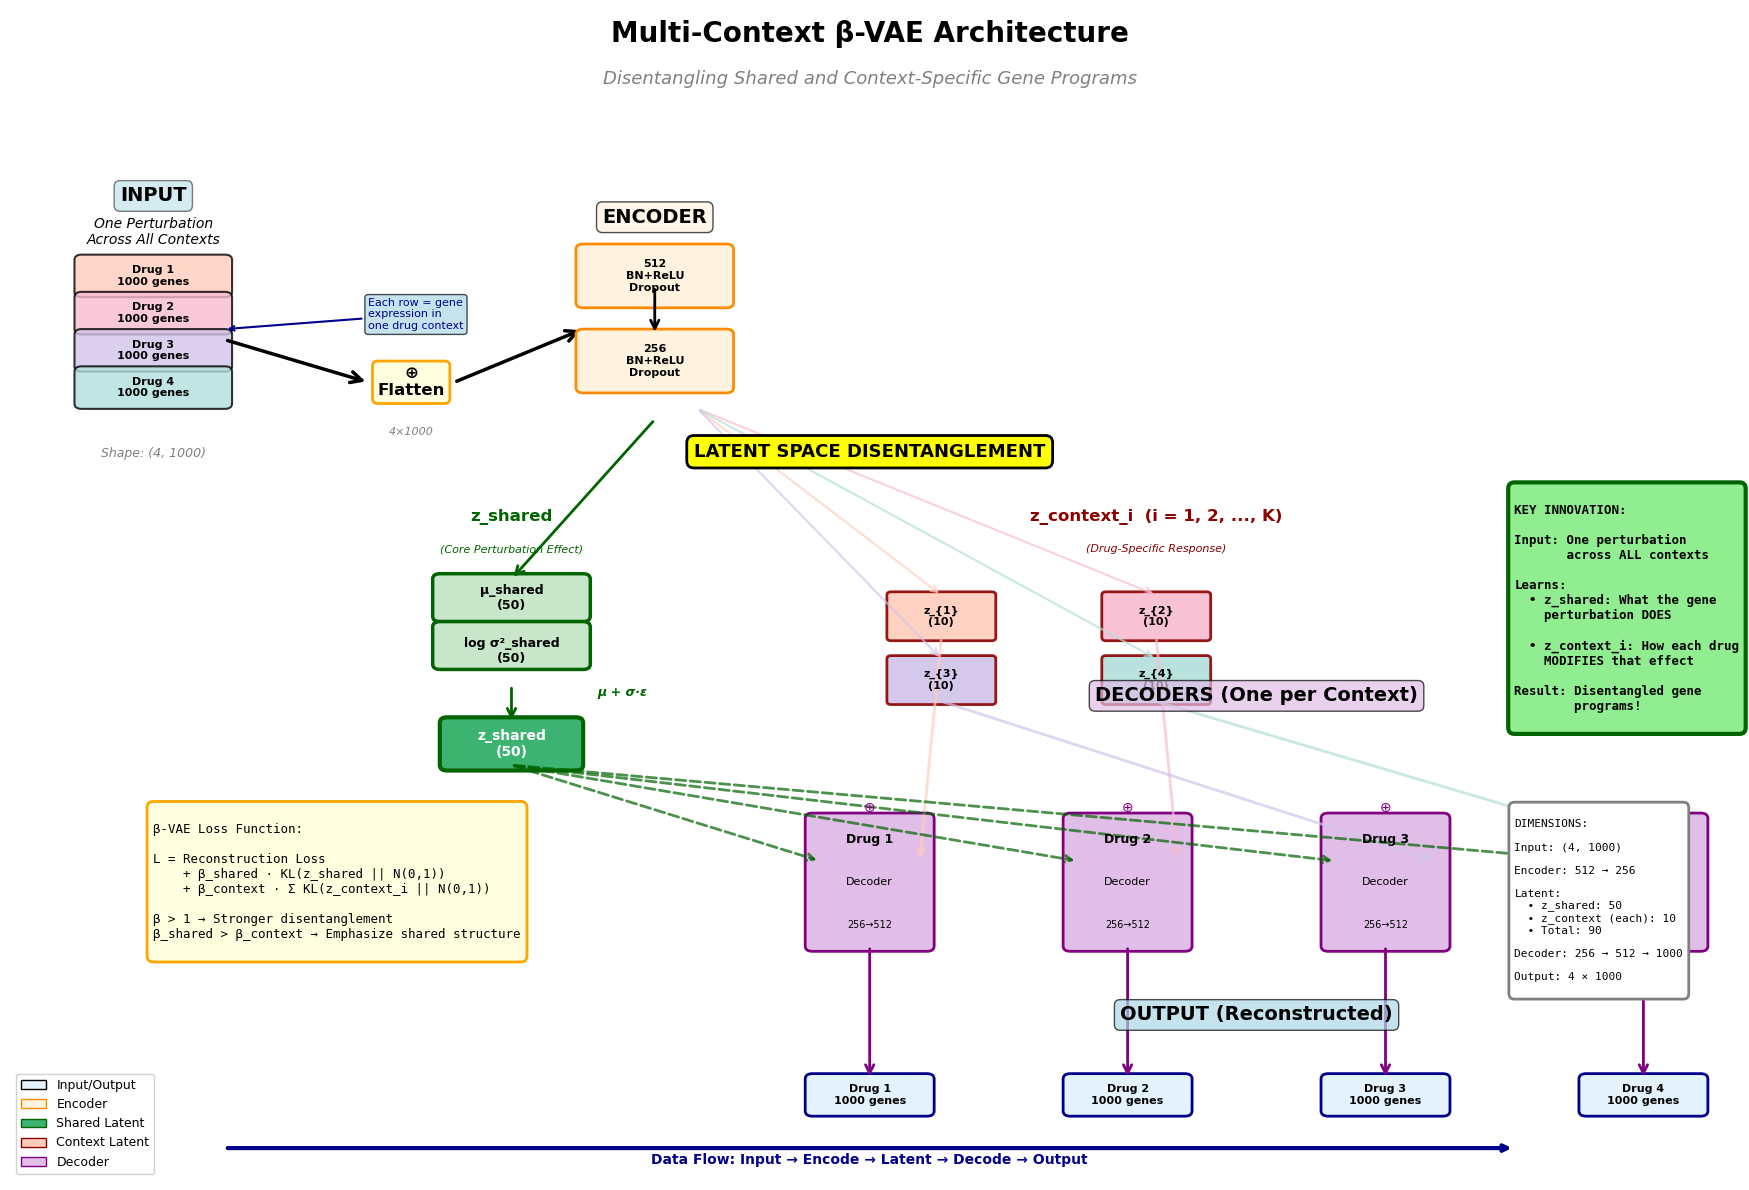

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_architecture(
    n_genes=1000,
    n_contexts=4,
    n_shared_latent=50,
    n_context_latent=10,
    hidden_dims=[512, 256],
    figsize=(18, 12)
):
    """
    Visualize the Multi-Context β-VAE architecture.
    
    Key innovation: Each input is one perturbation across ALL drug contexts
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder = '#FFF3E0'
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9', '#B2DFDB']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = [f'Drug {i+1}' for i in range(n_contexts)]
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=20, fontweight='bold')
    ax.text(6, 10.3, 'Disentangling Shared and Context-Specific Gene Programs', 
            ha='center', fontsize=13, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.0
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=10, style='italic')
    
    # Draw stacked contexts
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.35
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.5, y_pos - 0.15), 1.0, 0.3,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=1.5,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\n{n_genes} genes', 
                ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Input annotation
    ax.annotate('Each row = gene\nexpression in\none drug context', 
                xy=(input_x + 0.5, input_y_start - 0.5), 
                xytext=(input_x + 1.5, input_y_start - 0.5),
                fontsize=8, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    # Shape annotation
    ax.text(input_x, input_y_start - n_contexts * 0.35 - 0.3, 
            f'Shape: ({n_contexts}, {n_genes})', 
            ha='center', fontsize=9, style='italic', color='gray')
    
    # ============================================================
    # CONCATENATION
    # ============================================================
    
    concat_x = 2.8
    concat_y = 7.5
    
    ax.text(concat_x, concat_y, '⊕\nFlatten', 
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2))
    
    # Arrow to concatenation
    arrow = FancyArrowPatch(
        (input_x + 0.5, input_y_start - 0.6), (concat_x - 0.3, concat_y),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
    )
    ax.add_patch(arrow)
    
    ax.text(concat_x, concat_y - 0.5, f'{n_contexts}×{n_genes}', 
            ha='center', fontsize=8, style='italic', color='gray')
    
    # ============================================================
    # ENCODER
    # ============================================================
    
    encoder_x = 4.5
    encoder_y_start = 8.5
    
    ax.text(encoder_x, encoder_y_start + 0.5, 'ENCODER', 
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color_encoder, alpha=0.7))
    
    # Arrow to encoder
    arrow = FancyArrowPatch(
        (concat_x + 0.3, concat_y), (encoder_x - 0.5, encoder_y_start - 0.5),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
    )
    ax.add_patch(arrow)
    
    # Hidden layers
    y_offset = encoder_y_start
    for i, hidden_dim in enumerate(hidden_dims):
        box = FancyBboxPatch(
            (encoder_x - 0.5, y_offset - 0.25), 1.0, 0.5,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder, 
            edgecolor='darkorange',
            linewidth=2
        )
        ax.add_patch(box)
        ax.text(encoder_x, y_offset, f'{hidden_dim}\nBN+ReLU\nDropout', 
                ha='center', va='center', fontsize=8, fontweight='bold')
        
        if i > 0:
            arrow = FancyArrowPatch(
                (encoder_x, y_offset + 0.7), (encoder_x, y_offset + 0.25),
                arrowstyle='->', mutation_scale=15, linewidth=2, color='black'
            )
            ax.add_patch(arrow)
        
        y_offset -= 0.8
    
    encoder_y_end = y_offset + 0.25
    
    # ============================================================
    # LATENT SPACE (The key innovation!)
    # ============================================================
    
    latent_y = 5.0
    
    # Central split indicator
    ax.text(6, latent_y + 1.8, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                     edgecolor='black', linewidth=2))
    
    # Shared latent (LEFT)
    shared_x = 3.5
    
    ax.text(shared_x, latent_y + 1.2, 'z_shared', 
            ha='center', fontsize=12, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.9, '(Core Perturbation Effect)', 
            ha='center', fontsize=8, style='italic', color='darkgreen')
    
    # μ and log σ² for shared
    mu_box = FancyBboxPatch(
        (shared_x - 0.5, latent_y + 0.3), 1.0, 0.35,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=2.5
    )
    ax.add_patch(mu_box)
    ax.text(shared_x, latent_y + 0.475, f'μ_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=9, fontweight='bold')
    
    logvar_box = FancyBboxPatch(
        (shared_x - 0.5, latent_y - 0.15), 1.0, 0.35,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=2.5
    )
    ax.add_patch(logvar_box)
    ax.text(shared_x, latent_y - 0.025, f'log σ²_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Arrow from encoder
    arrow = FancyArrowPatch(
        (encoder_x, encoder_y_end), (shared_x, latent_y + 0.65),
        arrowstyle='->', mutation_scale=15, linewidth=2, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # Reparameterization for shared
    z_shared_y = latent_y - 0.9
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.45, z_shared_y - 0.2), 0.9, 0.4,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, z_shared_y, f'z_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Reparameterization arrow
    arrow = FancyArrowPatch(
        (shared_x, latent_y - 0.35), (shared_x, z_shared_y + 0.2),
        arrowstyle='->', mutation_scale=15, linewidth=2, color='darkgreen'
    )
    ax.add_patch(arrow)
    ax.text(shared_x + 0.6, (latent_y + z_shared_y) / 2, 'μ + σ·ε', 
            fontsize=9, style='italic', color='darkgreen', fontweight='bold')
    
    # Context-specific latents (RIGHT, stacked)
    context_x_start = 6.5
    context_spacing = 1.5
    
    ax.text(context_x_start + context_spacing, latent_y + 1.2, 
            'z_context_i  (i = 1, 2, ..., K)', 
            ha='center', fontsize=12, fontweight='bold', color='darkred')
    ax.text(context_x_start + context_spacing, latent_y + 0.9, 
            '(Drug-Specific Response)', 
            ha='center', fontsize=8, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_x = context_x_start + (i % 2) * context_spacing
        ctx_y = latent_y + 0.3 - (i // 2) * 0.6
        
        # Small box for this context
        ctx_box = FancyBboxPatch(
            (ctx_x - 0.35, ctx_y - 0.2), 0.7, 0.4,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(ctx_x, ctx_y, f'z_{{{i+1}}}\n({n_context_latent})', 
                ha='center', va='center', fontsize=8, fontweight='bold')
        
        # Arrow from encoder
        arrow = FancyArrowPatch(
            (encoder_x + 0.3, encoder_y_end + 0.1), (ctx_x, ctx_y + 0.2),
            arrowstyle='->', mutation_scale=12, linewidth=1.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODER (Multiple, one per context)
    # ============================================================
    
    decoder_y_start = 2.5
    decoder_x_start = 6.0
    decoder_spacing = 1.8
    
    ax.text(decoder_x_start + decoder_spacing * 1.5, decoder_y_start + 2.0, 
            'DECODERS (One per Context)', 
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color_decoder, alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Decoder box
        dec_box = FancyBboxPatch(
            (dec_x - 0.4, decoder_y_start - 0.3), 0.8, 1.2,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.7, f'{ctx_name}', 
                ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.3, 'Decoder', 
                ha='center', va='center', fontsize=8)
        ax.text(dec_x, decoder_y_start - 0.1, f'{hidden_dims[-1]}→{hidden_dims[-2]}', 
                ha='center', va='center', fontsize=7)
        
        # Input to decoder: [z_shared, z_context_i]
        ctx_idx = i
        ctx_latent_x = context_x_start + (ctx_idx % 2) * context_spacing
        ctx_latent_y = latent_y + 0.3 - (ctx_idx // 2) * 0.6
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, z_shared_y - 0.2), (dec_x - 0.35, decoder_y_start + 0.5),
            arrowstyle='->', mutation_scale=12, linewidth=2, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (ctx_latent_x, ctx_latent_y - 0.2), (dec_x + 0.35, decoder_y_start + 0.5),
            arrowstyle='->', mutation_scale=12, linewidth=2, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 1.0, '⊕', 
                ha='center', va='center', fontsize=10, color='purple')
    
    # ============================================================
    # OUTPUT (Reconstructed contexts)
    # ============================================================
    
    output_y_start = 0.8
    
    ax.text(decoder_x_start + decoder_spacing * 1.5, output_y_start + 0.7, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box
        out_box = FancyBboxPatch(
            (out_x - 0.4, output_y_start - 0.15), 0.8, 0.3,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\n{n_genes} genes', 
                ha='center', va='center', fontsize=8, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.3), (out_x, output_y_start + 0.15),
            arrowstyle='->', mutation_scale=15, linewidth=2, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # β-VAE LOSS ANNOTATION
    # ============================================================
    
    loss_text = """
β-VAE Loss Function:

L = Reconstruction Loss
    + β_shared · KL(z_shared || N(0,1))
    + β_context · Σ KL(z_context_i || N(0,1))

β > 1 → Stronger disentanglement
β_shared > β_context → Emphasize shared structure
    """
    
    ax.text(1.0, 3.5, loss_text, 
            fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2),
            verticalalignment='top',
            family='monospace')
    
    # ============================================================
    # KEY INNOVATION BOX
    # ============================================================
    
    innovation_text = """
KEY INNOVATION:

Input: One perturbation
       across ALL contexts

Learns:
  • z_shared: What the gene
    perturbation DOES
    
  • z_context_i: How each drug
    MODIFIES that effect

Result: Disentangled gene
        programs!
    """
    
    ax.text(10.5, 6.5, innovation_text, 
            fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', 
                     edgecolor='darkgreen', linewidth=3),
            verticalalignment='top',
            family='monospace',
            fontweight='bold')
    
    # ============================================================
    # DIMENSIONS SUMMARY
    # ============================================================
    
    dims_text = f"""
DIMENSIONS:

Input: ({n_contexts}, {n_genes})

Encoder: {' → '.join(map(str, hidden_dims))}

Latent:
  • z_shared: {n_shared_latent}
  • z_context (each): {n_context_latent}
  • Total: {n_shared_latent + n_contexts * n_context_latent}

Decoder: {' → '.join(map(str, reversed(hidden_dims)))} → {n_genes}

Output: {n_contexts} × {n_genes}
    """
    
    ax.text(10.5, 3.5, dims_text, 
            fontsize=8, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='gray', linewidth=2),
            verticalalignment='top',
            family='monospace')
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder, edgecolor='darkorange', label='Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.3), xytext=(1.5, 0.3),
                arrowprops=dict(arrowstyle='->', lw=3, color='darkblue'))
    ax.text(6, 0.15, 'Data Flow: Input → Encode → Latent → Decode → Output', 
            ha='center', fontsize=10, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_architecture(
    n_genes=1000,
    n_contexts=4,
    n_shared_latent=50,
    n_context_latent=10,
    hidden_dims=[512, 256],
    figsize=(18, 12)
)

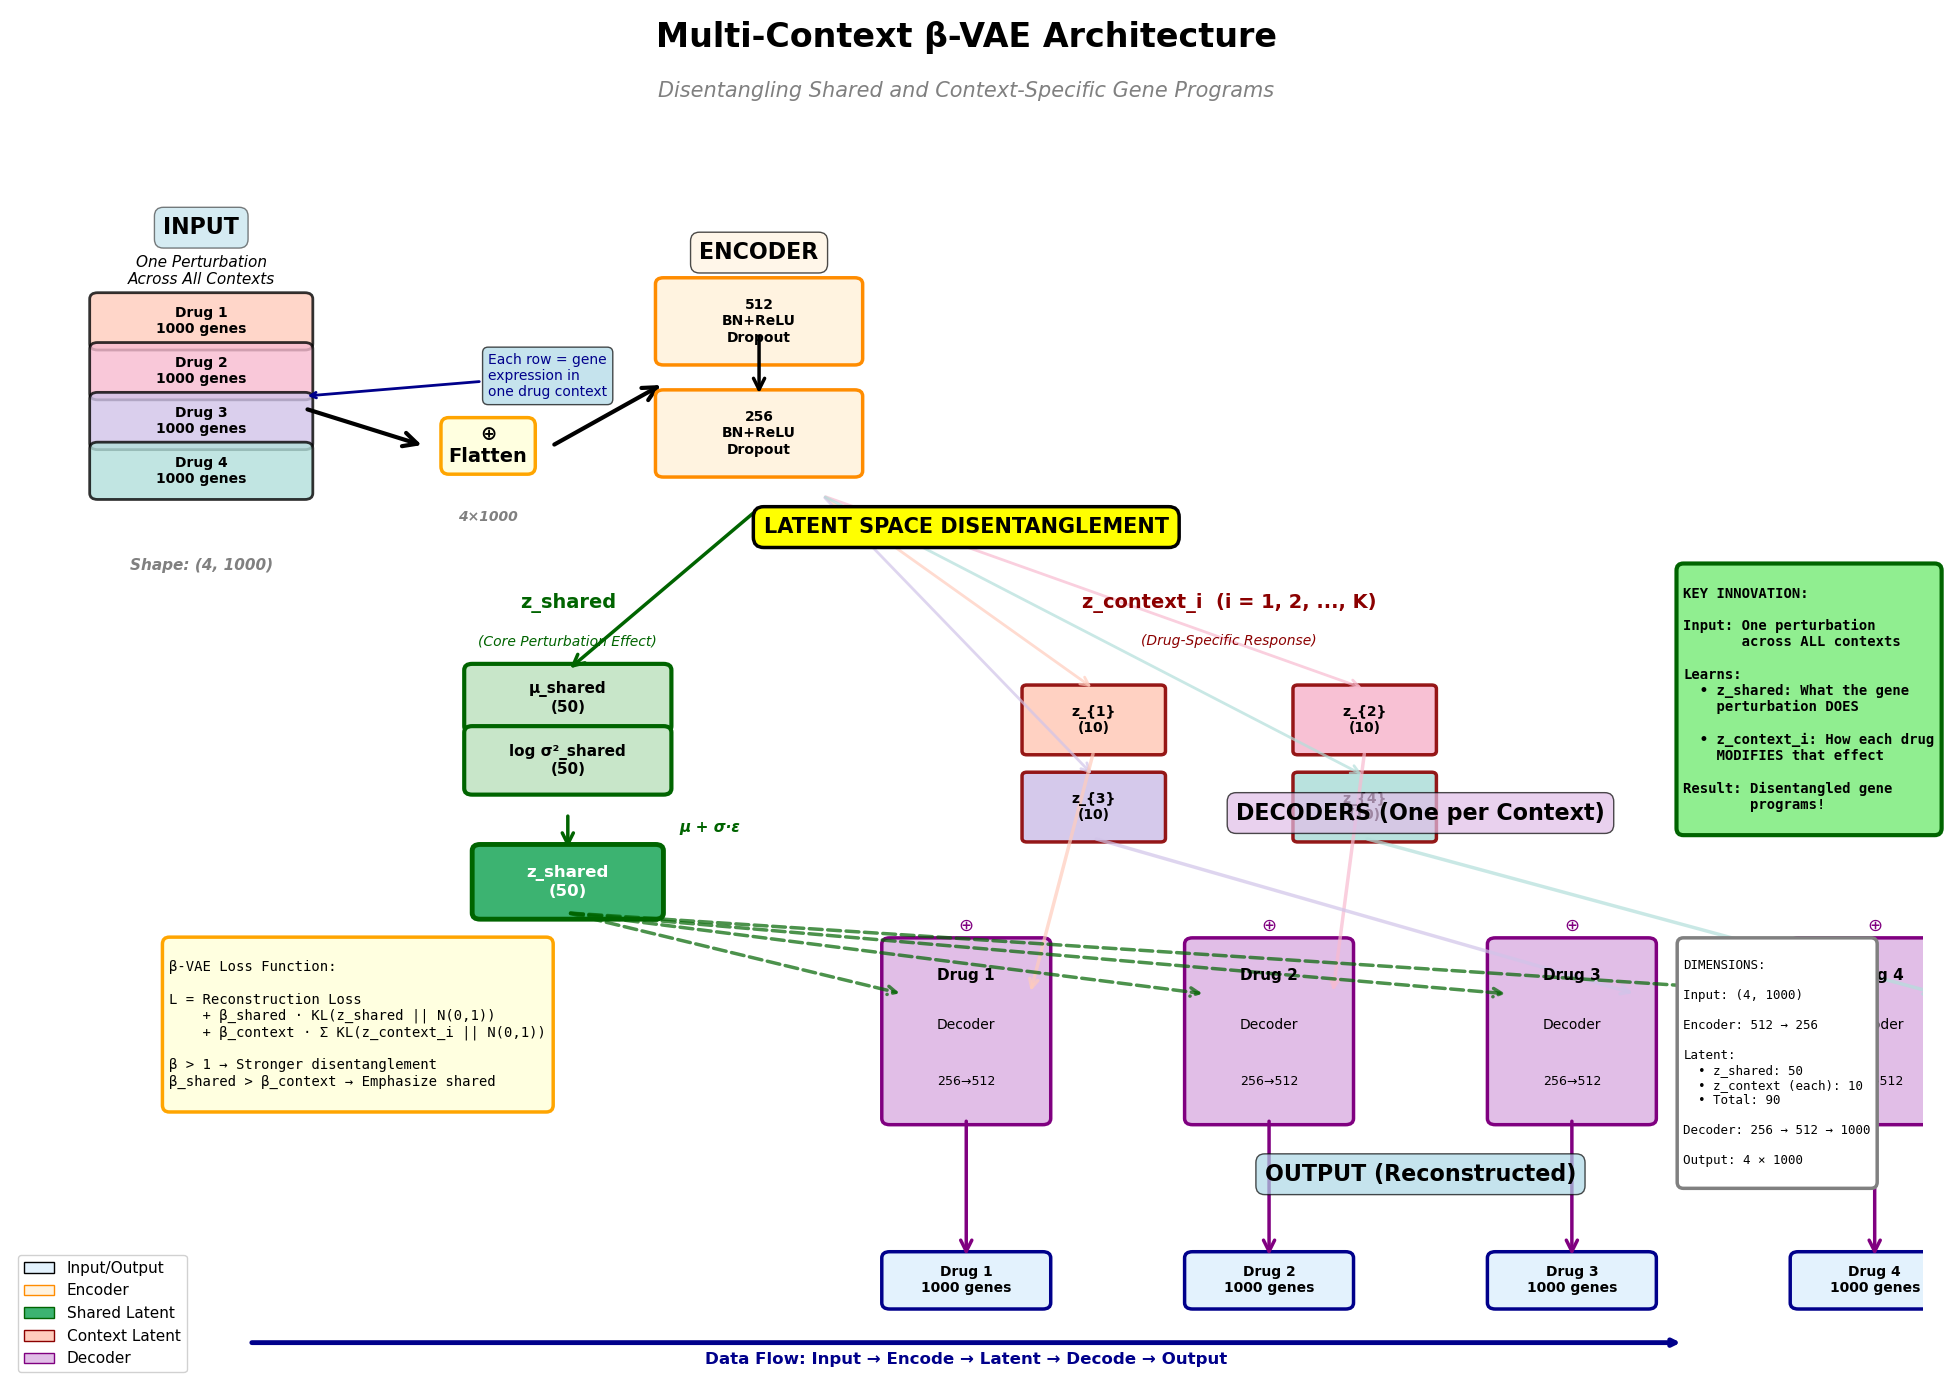

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_architecture(
    n_genes=1000,
    n_contexts=4,
    n_shared_latent=50,
    n_context_latent=10,
    hidden_dims=[512, 256],
    figsize=(20, 14)
):
    """
    Visualize the Multi-Context β-VAE architecture.
    
    Key innovation: Each input is one perturbation across ALL drug contexts
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder = '#FFF3E0'
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9', '#B2DFDB']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = [f'Drug {i+1}' for i in range(n_contexts)]
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=24, fontweight='bold')
    ax.text(6, 10.3, 'Disentangling Shared and Context-Specific Gene Programs', 
            ha='center', fontsize=15, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.2
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=11, style='italic')
    
    # Draw stacked contexts (BIGGER boxes)
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.4
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.65, y_pos - 0.18), 1.3, 0.36,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=2,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\n{n_genes} genes', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Input annotation
    ax.annotate('Each row = gene\nexpression in\none drug context', 
                xy=(input_x + 0.65, input_y_start - 0.6), 
                xytext=(input_x + 1.8, input_y_start - 0.6),
                fontsize=10, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=2),
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    # Shape annotation
    ax.text(input_x, input_y_start - n_contexts * 0.4 - 0.4, 
            f'Shape: ({n_contexts}, {n_genes})', 
            ha='center', fontsize=11, style='italic', color='gray',
            fontweight='bold')
    
    # ============================================================
    # CONCATENATION
    # ============================================================
    
    concat_x = 3.0
    concat_y = 7.5
    
    ax.text(concat_x, concat_y, '⊕\nFlatten', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5))
    
    # Arrow to concatenation
    arrow = FancyArrowPatch(
        (input_x + 0.65, input_y_start - 0.7), (concat_x - 0.4, concat_y),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    ax.text(concat_x, concat_y - 0.6, f'{n_contexts}×{n_genes}', 
            ha='center', fontsize=10, style='italic', color='gray',
            fontweight='bold')
    
    # ============================================================
    # ENCODER
    # ============================================================
    
    encoder_x = 4.7
    encoder_y_start = 8.5
    
    ax.text(encoder_x, encoder_y_start + 0.5, 'ENCODER', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_encoder, alpha=0.7))
    
    # Arrow to encoder
    arrow = FancyArrowPatch(
        (concat_x + 0.4, concat_y), (encoder_x - 0.6, encoder_y_start - 0.5),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # Hidden layers (BIGGER boxes)
    y_offset = encoder_y_start
    for i, hidden_dim in enumerate(hidden_dims):
        box = FancyBboxPatch(
            (encoder_x - 0.6, y_offset - 0.3), 1.2, 0.6,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder, 
            edgecolor='darkorange',
            linewidth=2.5
        )
        ax.add_patch(box)
        ax.text(encoder_x, y_offset, f'{hidden_dim}\nBN+ReLU\nDropout', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        if i > 0:
            arrow = FancyArrowPatch(
                (encoder_x, y_offset + 0.8), (encoder_x, y_offset + 0.3),
                arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
            )
            ax.add_patch(arrow)
        
        y_offset -= 0.9
    
    encoder_y_end = y_offset + 0.3
    
    # ============================================================
    # LATENT SPACE (The key innovation!)
    # ============================================================
    
    latent_y = 5.0
    
    # Central split indicator
    ax.text(6, latent_y + 1.8, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                     edgecolor='black', linewidth=2.5))
    
    # Shared latent (LEFT) - BIGGER
    shared_x = 3.5
    
    ax.text(shared_x, latent_y + 1.2, 'z_shared', 
            ha='center', fontsize=14, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.9, '(Core Perturbation Effect)', 
            ha='center', fontsize=10, style='italic', color='darkgreen')
    
    # μ and log σ² for shared - BIGGER boxes
    mu_box = FancyBboxPatch(
        (shared_x - 0.6, latent_y + 0.25), 1.2, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(mu_box)
    ax.text(shared_x, latent_y + 0.475, f'μ_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    logvar_box = FancyBboxPatch(
        (shared_x - 0.6, latent_y - 0.25), 1.2, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(logvar_box)
    ax.text(shared_x, latent_y - 0.025, f'log σ²_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Arrow from encoder
    arrow = FancyArrowPatch(
        (encoder_x, encoder_y_end), (shared_x, latent_y + 0.7),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # Reparameterization for shared - BIGGER
    z_shared_y = latent_y - 1.0
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.55, z_shared_y - 0.25), 1.1, 0.5,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3.5
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, z_shared_y, f'z_shared\n({n_shared_latent})', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Reparameterization arrow
    arrow = FancyArrowPatch(
        (shared_x, latent_y - 0.45), (shared_x, z_shared_y + 0.25),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    ax.text(shared_x + 0.7, (latent_y + z_shared_y) / 2 - 0.1, 'μ + σ·ε', 
            fontsize=11, style='italic', color='darkgreen', fontweight='bold')
    
    # Context-specific latents (RIGHT, stacked) - BIGGER
    context_x_start = 6.8
    context_spacing = 1.7
    
    ax.text(context_x_start + context_spacing * 0.5, latent_y + 1.2, 
            'z_context_i  (i = 1, 2, ..., K)', 
            ha='center', fontsize=14, fontweight='bold', color='darkred')
    ax.text(context_x_start + context_spacing * 0.5, latent_y + 0.9, 
            '(Drug-Specific Response)', 
            ha='center', fontsize=10, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_x = context_x_start + (i % 2) * context_spacing
        ctx_y = latent_y + 0.3 - (i // 2) * 0.7
        
        # Small box for this context - BIGGER
        ctx_box = FancyBboxPatch(
            (ctx_x - 0.42, ctx_y - 0.25), 0.84, 0.5,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(ctx_x, ctx_y, f'z_{{{i+1}}}\n({n_context_latent})', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from encoder
        arrow = FancyArrowPatch(
            (encoder_x + 0.4, encoder_y_end + 0.1), (ctx_x, ctx_y + 0.25),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODER (Multiple, one per context) - BIGGER
    # ============================================================
    
    decoder_y_start = 2.5
    decoder_x_start = 6.0
    decoder_spacing = 1.9
    
    ax.text(decoder_x_start + decoder_spacing * 1.5, decoder_y_start + 2.0, 
            'DECODERS (One per Context)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_decoder, alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Decoder box - BIGGER
        dec_box = FancyBboxPatch(
            (dec_x - 0.48, decoder_y_start - 0.4), 0.96, 1.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2.5
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.75, f'{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.35, 'Decoder', 
                ha='center', va='center', fontsize=10)
        ax.text(dec_x, decoder_y_start - 0.1, f'{hidden_dims[-1]}→{hidden_dims[-2]}', 
                ha='center', va='center', fontsize=9)
        
        # Input to decoder: [z_shared, z_context_i]
        ctx_idx = i
        ctx_latent_x = context_x_start + (ctx_idx % 2) * context_spacing
        ctx_latent_y = latent_y + 0.3 - (ctx_idx // 2) * 0.7
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, z_shared_y - 0.25), (dec_x - 0.4, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (ctx_latent_x, ctx_latent_y - 0.25), (dec_x + 0.4, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 1.15, '⊕', 
                ha='center', va='center', fontsize=13, color='purple')
    
    # ============================================================
    # OUTPUT (Reconstructed contexts) - BIGGER
    # ============================================================
    
    output_y_start = 0.8
    
    ax.text(decoder_x_start + decoder_spacing * 1.5, output_y_start + 0.8, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box - BIGGER
        out_box = FancyBboxPatch(
            (out_x - 0.48, output_y_start - 0.18), 0.96, 0.36,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2.5
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\n{n_genes} genes', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.4), (out_x, output_y_start + 0.18),
            arrowstyle='->', mutation_scale=20, linewidth=2.5, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # β-VAE LOSS ANNOTATION
    # ============================================================
    
    loss_text = """
β-VAE Loss Function:

L = Reconstruction Loss
    + β_shared · KL(z_shared || N(0,1))
    + β_context · Σ KL(z_context_i || N(0,1))

β > 1 → Stronger disentanglement
β_shared > β_context → Emphasize shared
    """
    
    ax.text(1.0, 3.5, loss_text, 
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5),
            verticalalignment='top',
            family='monospace')
    
    # ============================================================
    # KEY INNOVATION BOX
    # ============================================================
    
    innovation_text = """
KEY INNOVATION:

Input: One perturbation
       across ALL contexts

Learns:
  • z_shared: What the gene
    perturbation DOES
    
  • z_context_i: How each drug
    MODIFIES that effect

Result: Disentangled gene
        programs!
    """
    
    ax.text(10.5, 6.5, innovation_text, 
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', 
                     edgecolor='darkgreen', linewidth=3),
            verticalalignment='top',
            family='monospace',
            fontweight='bold')
    
    # ============================================================
    # DIMENSIONS SUMMARY
    # ============================================================
    
    dims_text = f"""
DIMENSIONS:

Input: ({n_contexts}, {n_genes})

Encoder: {' → '.join(map(str, hidden_dims))}

Latent:
  • z_shared: {n_shared_latent}
  • z_context (each): {n_context_latent}
  • Total: {n_shared_latent + n_contexts * n_context_latent}

Decoder: {' → '.join(map(str, reversed(hidden_dims)))} → {n_genes}

Output: {n_contexts} × {n_genes}
    """
    
    ax.text(10.5, 3.5, dims_text, 
            fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='gray', linewidth=2.5),
            verticalalignment='top',
            family='monospace')
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder, edgecolor='darkorange', label='Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=11, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.3), xytext=(1.5, 0.3),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='darkblue'))
    ax.text(6, 0.13, 'Data Flow: Input → Encode → Latent → Decode → Output', 
            ha='center', fontsize=12, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_architecture(
    n_genes=1000,
    n_contexts=4,
    n_shared_latent=50,
    n_context_latent=10,
    hidden_dims=[512, 256],
    figsize=(20, 14)  # Increased from (18, 12)
)

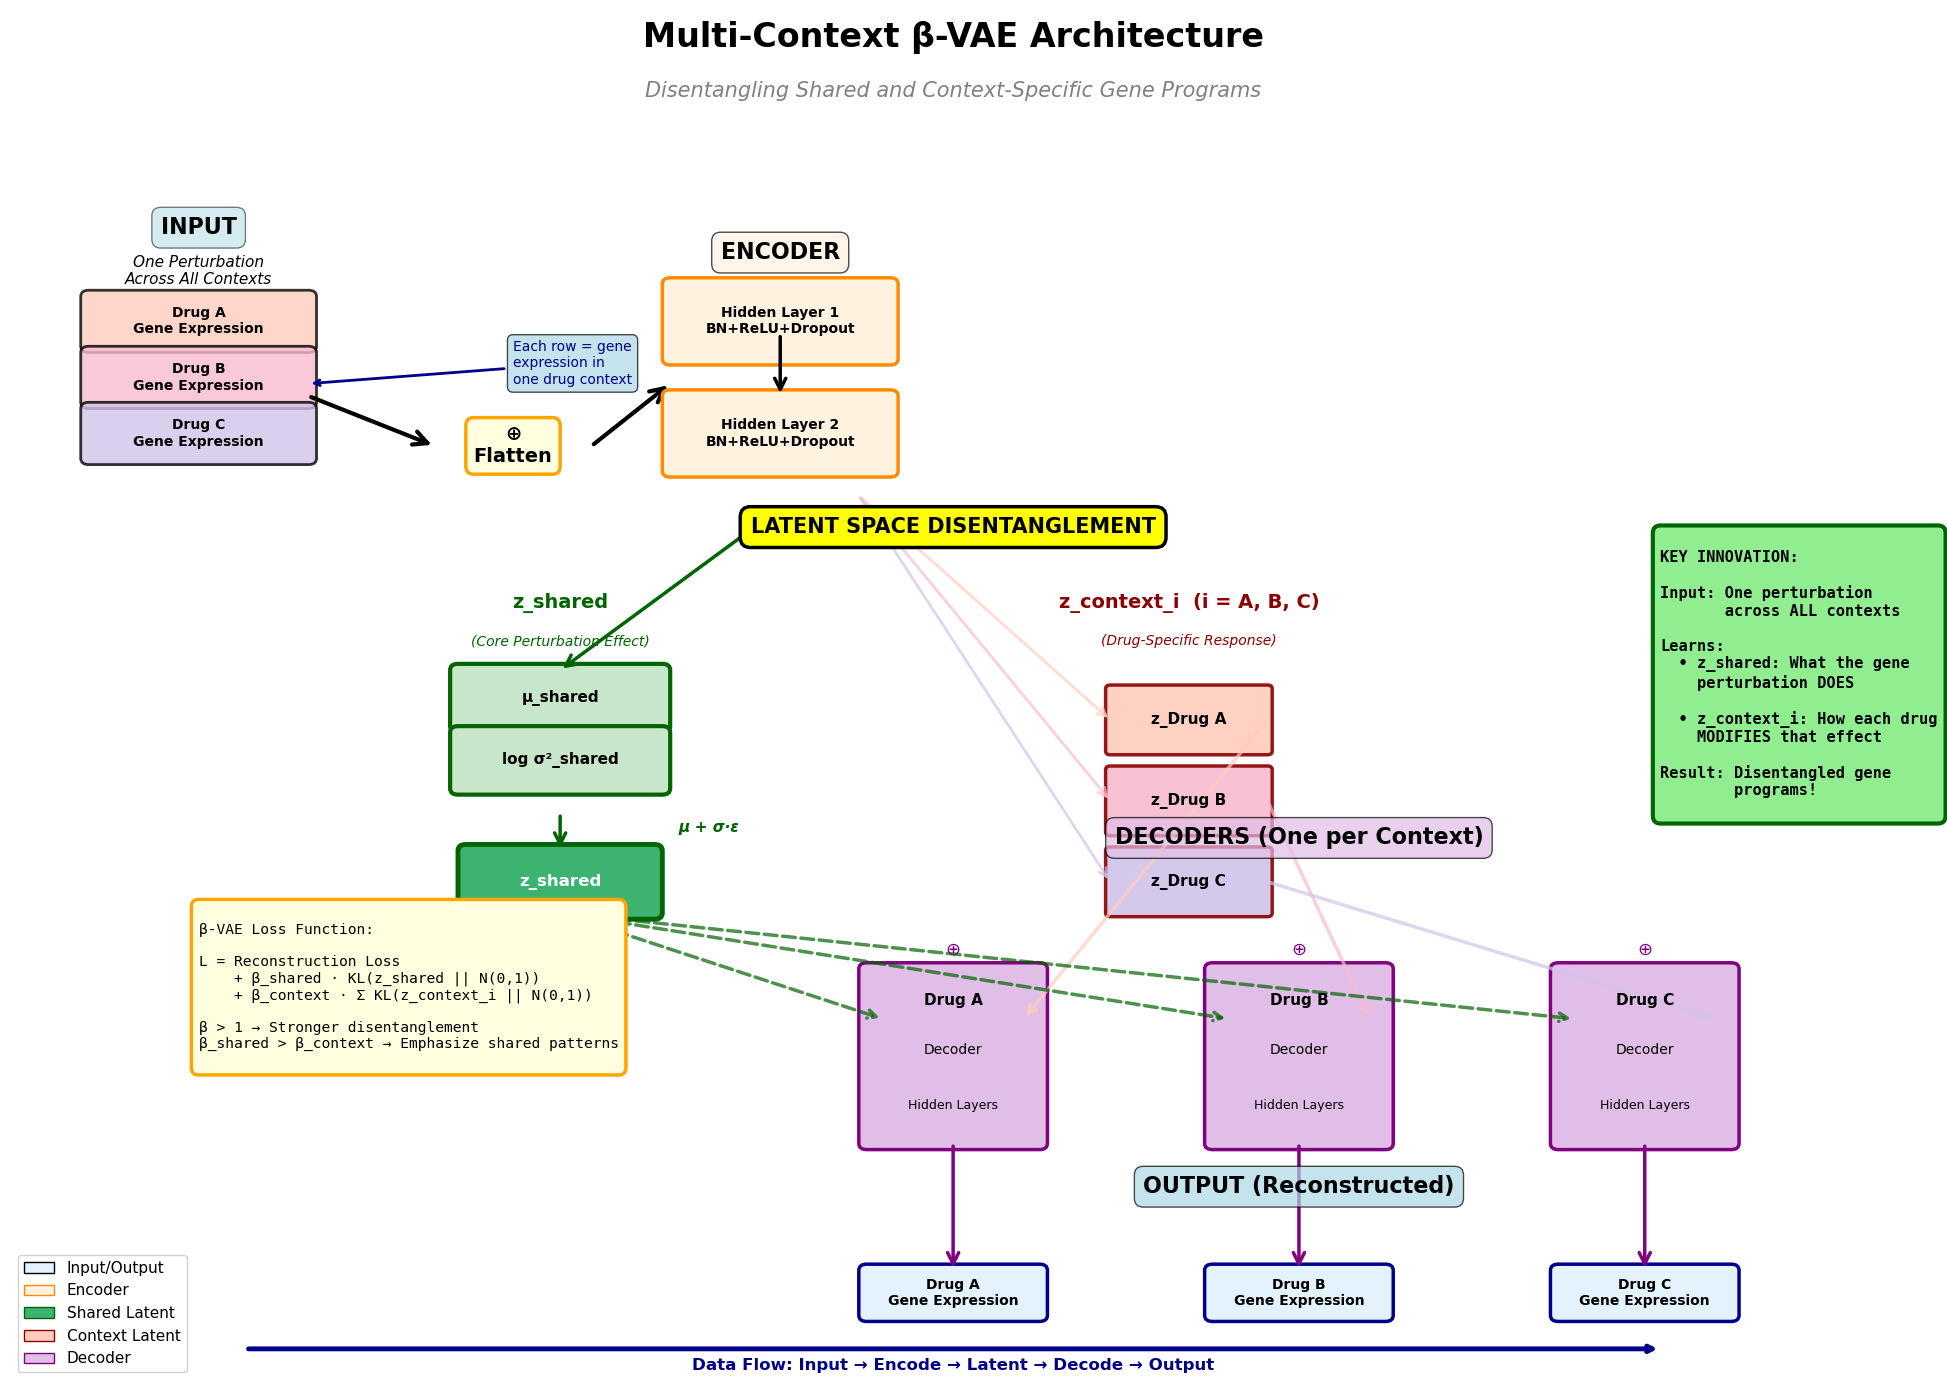

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
):
    """
    Visualize the Multi-Context β-VAE architecture.
    
    Key innovation: Each input is one perturbation across ALL drug contexts
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder = '#FFF3E0'
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = ['Drug A', 'Drug B', 'Drug C']
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=24, fontweight='bold')
    ax.text(6, 10.3, 'Disentangling Shared and Context-Specific Gene Programs', 
            ha='center', fontsize=15, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.2
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=11, style='italic')
    
    # Draw stacked contexts
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.45
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.7, y_pos - 0.2), 1.4, 0.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=2,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\nGene Expression', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Input annotation
    ax.annotate('Each row = gene\nexpression in\none drug context', 
                xy=(input_x + 0.7, input_y_start - 0.5), 
                xytext=(input_x + 2.0, input_y_start - 0.5),
                fontsize=10, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=2),
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    # ============================================================
    # CONCATENATION
    # ============================================================
    
    concat_x = 3.2
    concat_y = 7.5
    
    ax.text(concat_x, concat_y, '⊕\nFlatten', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5))
    
    # Arrow to concatenation
    arrow = FancyArrowPatch(
        (input_x + 0.7, input_y_start - 0.6), (concat_x - 0.5, concat_y),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # ============================================================
    # ENCODER
    # ============================================================
    
    encoder_x = 4.9
    encoder_y_start = 8.5
    
    ax.text(encoder_x, encoder_y_start + 0.5, 'ENCODER', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_encoder, alpha=0.7))
    
    # Arrow to encoder
    arrow = FancyArrowPatch(
        (concat_x + 0.5, concat_y), (encoder_x - 0.7, encoder_y_start - 0.5),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # Hidden layers (simplified - just show the concept)
    y_offset = encoder_y_start
    for i in range(2):
        box = FancyBboxPatch(
            (encoder_x - 0.7, y_offset - 0.3), 1.4, 0.6,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder, 
            edgecolor='darkorange',
            linewidth=2.5
        )
        ax.add_patch(box)
        ax.text(encoder_x, y_offset, f'Hidden Layer {i+1}\nBN+ReLU+Dropout', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        if i > 0:
            arrow = FancyArrowPatch(
                (encoder_x, y_offset + 0.8), (encoder_x, y_offset + 0.3),
                arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
            )
            ax.add_patch(arrow)
        
        y_offset -= 0.9
    
    encoder_y_end = y_offset + 0.3
    
    # ============================================================
    # LATENT SPACE (The key innovation!)
    # ============================================================
    
    latent_y = 5.0
    
    # Central split indicator
    ax.text(6, latent_y + 1.8, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                     edgecolor='black', linewidth=2.5))
    
    # Shared latent (LEFT)
    shared_x = 3.5
    
    ax.text(shared_x, latent_y + 1.2, 'z_shared', 
            ha='center', fontsize=14, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.9, '(Core Perturbation Effect)', 
            ha='center', fontsize=10, style='italic', color='darkgreen')
    
    # μ and log σ² for shared
    mu_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y + 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(mu_box)
    ax.text(shared_x, latent_y + 0.475, 'μ_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    logvar_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y - 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(logvar_box)
    ax.text(shared_x, latent_y - 0.025, 'log σ²_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Arrow from encoder
    arrow = FancyArrowPatch(
        (encoder_x, encoder_y_end), (shared_x, latent_y + 0.7),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # Reparameterization for shared
    z_shared_y = latent_y - 1.0
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.6, z_shared_y - 0.25), 1.2, 0.5,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3.5
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, z_shared_y, 'z_shared', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Reparameterization arrow
    arrow = FancyArrowPatch(
        (shared_x, latent_y - 0.45), (shared_x, z_shared_y + 0.25),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    ax.text(shared_x + 0.75, (latent_y + z_shared_y) / 2 - 0.1, 'μ + σ·ε', 
            fontsize=11, style='italic', color='darkgreen', fontweight='bold')
    
    # Context-specific latents (RIGHT, vertical stack)
    context_x = 7.5
    
    ax.text(context_x, latent_y + 1.2, 
            'z_context_i  (i = A, B, C)', 
            ha='center', fontsize=14, fontweight='bold', color='darkred')
    ax.text(context_x, latent_y + 0.9, 
            '(Drug-Specific Response)', 
            ha='center', fontsize=10, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_y = latent_y + 0.3 - i * 0.65
        
        # Box for this context
        ctx_box = FancyBboxPatch(
            (context_x - 0.5, ctx_y - 0.25), 1.0, 0.5,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(context_x, ctx_y, f'z_{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        
        # Arrow from encoder
        arrow = FancyArrowPatch(
            (encoder_x + 0.5, encoder_y_end + 0.1), (context_x - 0.5, ctx_y),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODER (Multiple, one per context)
    # ============================================================
    
    decoder_y_start = 2.3
    decoder_x_start = 6.0
    decoder_spacing = 2.2
    
    ax.text(decoder_x_start + decoder_spacing, decoder_y_start + 2.0, 
            'DECODERS (One per Context)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_decoder, alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Decoder box
        dec_box = FancyBboxPatch(
            (dec_x - 0.55, decoder_y_start - 0.4), 1.1, 1.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2.5
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.75, f'{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.35, 'Decoder', 
                ha='center', va='center', fontsize=10)
        ax.text(dec_x, decoder_y_start - 0.1, 'Hidden Layers', 
                ha='center', va='center', fontsize=9)
        
        # Input to decoder: [z_shared, z_context_i]
        ctx_latent_y = latent_y + 0.3 - i * 0.65
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, z_shared_y - 0.25), (dec_x - 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (context_x + 0.5, ctx_latent_y), (dec_x + 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 1.15, '⊕', 
                ha='center', va='center', fontsize=13, color='purple')
    
    # ============================================================
    # OUTPUT (Reconstructed contexts)
    # ============================================================
    
    output_y_start = 0.7
    
    ax.text(decoder_x_start + decoder_spacing, output_y_start + 0.8, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box
        out_box = FancyBboxPatch(
            (out_x - 0.55, output_y_start - 0.18), 1.1, 0.36,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2.5
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\nGene Expression', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.4), (out_x, output_y_start + 0.18),
            arrowstyle='->', mutation_scale=20, linewidth=2.5, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # β-VAE LOSS ANNOTATION
    # ============================================================
    
    loss_text = """
β-VAE Loss Function:

L = Reconstruction Loss
    + β_shared · KL(z_shared || N(0,1))
    + β_context · Σ KL(z_context_i || N(0,1))

β > 1 → Stronger disentanglement
β_shared > β_context → Emphasize shared patterns
    """
    
    ax.text(1.2, 3.8, loss_text, 
            fontsize=10.5, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5),
            verticalalignment='top',
            family='monospace')
    
    # ============================================================
    # KEY INNOVATION BOX
    # ============================================================
    
    innovation_text = """
KEY INNOVATION:

Input: One perturbation
       across ALL contexts

Learns:
  • z_shared: What the gene
    perturbation DOES
    
  • z_context_i: How each drug
    MODIFIES that effect

Result: Disentangled gene
        programs!
    """
    
    ax.text(10.5, 6.8, innovation_text, 
            fontsize=11, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', 
                     edgecolor='darkgreen', linewidth=3),
            verticalalignment='top',
            family='monospace',
            fontweight='bold')
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder, edgecolor='darkorange', label='Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=11, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.25), xytext=(1.5, 0.25),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='darkblue'))
    ax.text(6, 0.08, 'Data Flow: Input → Encode → Latent → Decode → Output', 
            ha='center', fontsize=12, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
)

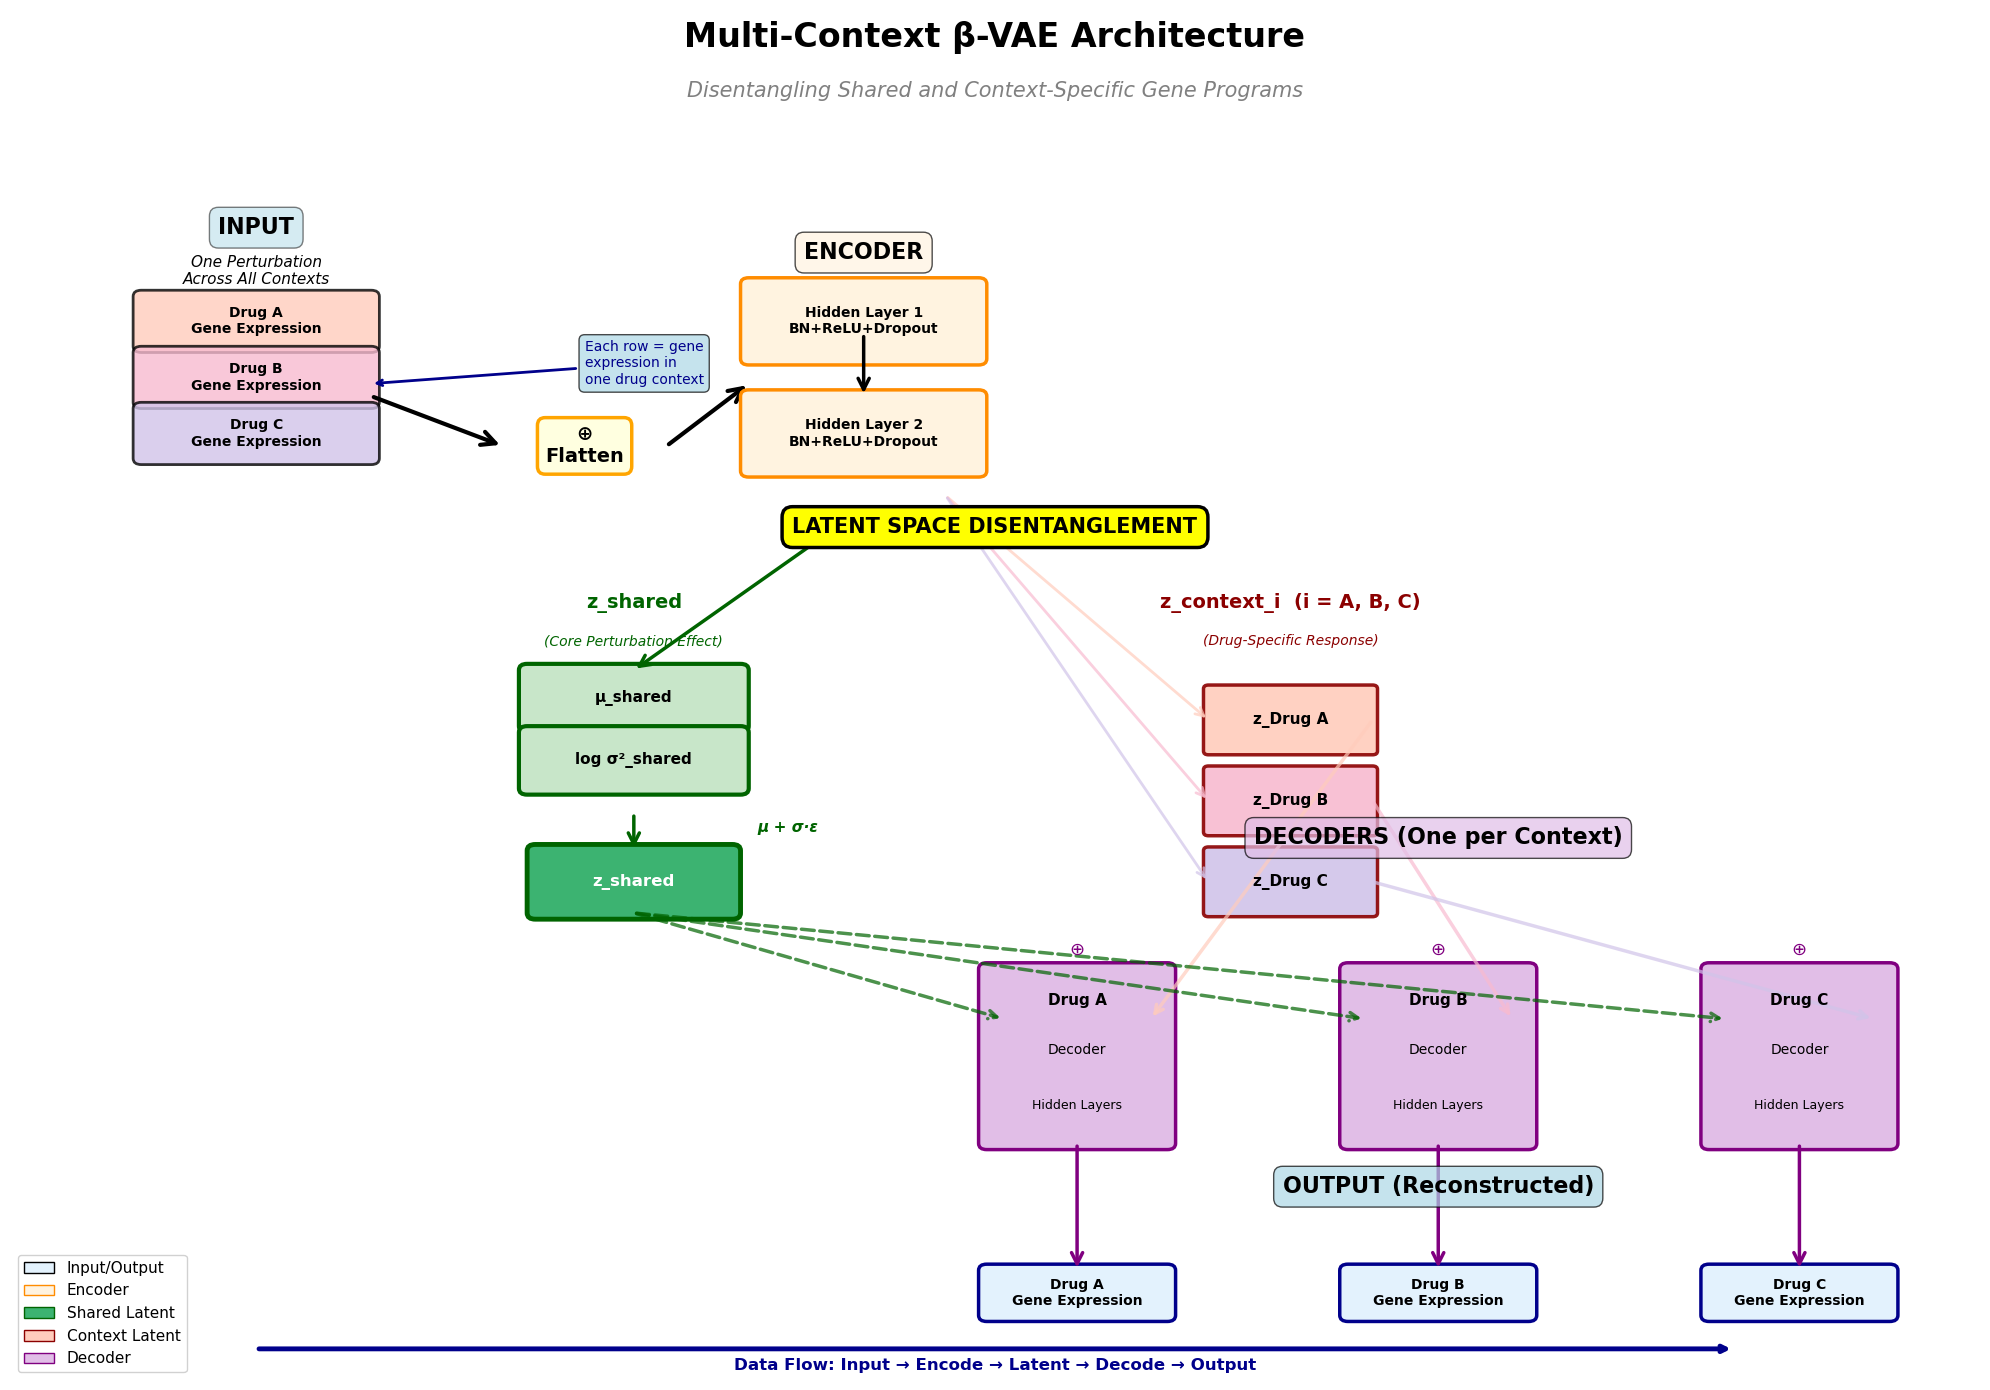

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
):
    """
    Visualize the Multi-Context β-VAE architecture.
    
    Key innovation: Each input is one perturbation across ALL drug contexts
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder = '#FFF3E0'
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = ['Drug A', 'Drug B', 'Drug C']
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=24, fontweight='bold')
    ax.text(6, 10.3, 'Disentangling Shared and Context-Specific Gene Programs', 
            ha='center', fontsize=15, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.5
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=11, style='italic')
    
    # Draw stacked contexts
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.45
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.7, y_pos - 0.2), 1.4, 0.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=2,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\nGene Expression', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Input annotation
    ax.annotate('Each row = gene\nexpression in\none drug context', 
                xy=(input_x + 0.7, input_y_start - 0.5), 
                xytext=(input_x + 2.0, input_y_start - 0.5),
                fontsize=10, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=2),
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    # ============================================================
    # CONCATENATION
    # ============================================================
    
    concat_x = 3.5
    concat_y = 7.5
    
    ax.text(concat_x, concat_y, '⊕\nFlatten', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5))
    
    # Arrow to concatenation
    arrow = FancyArrowPatch(
        (input_x + 0.7, input_y_start - 0.6), (concat_x - 0.5, concat_y),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # ============================================================
    # ENCODER
    # ============================================================
    
    encoder_x = 5.2
    encoder_y_start = 8.5
    
    ax.text(encoder_x, encoder_y_start + 0.5, 'ENCODER', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_encoder, alpha=0.7))
    
    # Arrow to encoder
    arrow = FancyArrowPatch(
        (concat_x + 0.5, concat_y), (encoder_x - 0.7, encoder_y_start - 0.5),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # Hidden layers (simplified - just show the concept)
    y_offset = encoder_y_start
    for i in range(2):
        box = FancyBboxPatch(
            (encoder_x - 0.7, y_offset - 0.3), 1.4, 0.6,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder, 
            edgecolor='darkorange',
            linewidth=2.5
        )
        ax.add_patch(box)
        ax.text(encoder_x, y_offset, f'Hidden Layer {i+1}\nBN+ReLU+Dropout', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        if i > 0:
            arrow = FancyArrowPatch(
                (encoder_x, y_offset + 0.8), (encoder_x, y_offset + 0.3),
                arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
            )
            ax.add_patch(arrow)
        
        y_offset -= 0.9
    
    encoder_y_end = y_offset + 0.3
    
    # ============================================================
    # LATENT SPACE (The key innovation!)
    # ============================================================
    
    latent_y = 5.0
    
    # Central split indicator
    ax.text(6, latent_y + 1.8, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                     edgecolor='black', linewidth=2.5))
    
    # Shared latent (LEFT)
    shared_x = 3.8
    
    ax.text(shared_x, latent_y + 1.2, 'z_shared', 
            ha='center', fontsize=14, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.9, '(Core Perturbation Effect)', 
            ha='center', fontsize=10, style='italic', color='darkgreen')
    
    # μ and log σ² for shared
    mu_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y + 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(mu_box)
    ax.text(shared_x, latent_y + 0.475, 'μ_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    logvar_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y - 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(logvar_box)
    ax.text(shared_x, latent_y - 0.025, 'log σ²_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Arrow from encoder
    arrow = FancyArrowPatch(
        (encoder_x, encoder_y_end), (shared_x, latent_y + 0.7),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # Reparameterization for shared
    z_shared_y = latent_y - 1.0
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.6, z_shared_y - 0.25), 1.2, 0.5,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3.5
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, z_shared_y, 'z_shared', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Reparameterization arrow
    arrow = FancyArrowPatch(
        (shared_x, latent_y - 0.45), (shared_x, z_shared_y + 0.25),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    ax.text(shared_x + 0.75, (latent_y + z_shared_y) / 2 - 0.1, 'μ + σ·ε', 
            fontsize=11, style='italic', color='darkgreen', fontweight='bold')
    
    # Context-specific latents (RIGHT, vertical stack)
    context_x = 7.8
    
    ax.text(context_x, latent_y + 1.2, 
            'z_context_i  (i = A, B, C)', 
            ha='center', fontsize=14, fontweight='bold', color='darkred')
    ax.text(context_x, latent_y + 0.9, 
            '(Drug-Specific Response)', 
            ha='center', fontsize=10, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_y = latent_y + 0.3 - i * 0.65
        
        # Box for this context
        ctx_box = FancyBboxPatch(
            (context_x - 0.5, ctx_y - 0.25), 1.0, 0.5,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(context_x, ctx_y, f'z_{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        
        # Arrow from encoder
        arrow = FancyArrowPatch(
            (encoder_x + 0.5, encoder_y_end + 0.1), (context_x - 0.5, ctx_y),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODER (Multiple, one per context)
    # ============================================================
    
    decoder_y_start = 2.3
    decoder_x_start = 6.5
    decoder_spacing = 2.2
    
    ax.text(decoder_x_start + decoder_spacing, decoder_y_start + 2.0, 
            'DECODERS (One per Context)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_decoder, alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Decoder box
        dec_box = FancyBboxPatch(
            (dec_x - 0.55, decoder_y_start - 0.4), 1.1, 1.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2.5
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.75, f'{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.35, 'Decoder', 
                ha='center', va='center', fontsize=10)
        ax.text(dec_x, decoder_y_start - 0.1, 'Hidden Layers', 
                ha='center', va='center', fontsize=9)
        
        # Input to decoder: [z_shared, z_context_i]
        ctx_latent_y = latent_y + 0.3 - i * 0.65
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, z_shared_y - 0.25), (dec_x - 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (context_x + 0.5, ctx_latent_y), (dec_x + 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 1.15, '⊕', 
                ha='center', va='center', fontsize=13, color='purple')
    
    # ============================================================
    # OUTPUT (Reconstructed contexts)
    # ============================================================
    
    output_y_start = 0.7
    
    ax.text(decoder_x_start + decoder_spacing, output_y_start + 0.8, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box
        out_box = FancyBboxPatch(
            (out_x - 0.55, output_y_start - 0.18), 1.1, 0.36,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2.5
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\nGene Expression', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.4), (out_x, output_y_start + 0.18),
            arrowstyle='->', mutation_scale=20, linewidth=2.5, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder, edgecolor='darkorange', label='Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=11, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.25), xytext=(1.5, 0.25),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='darkblue'))
    ax.text(6, 0.08, 'Data Flow: Input → Encode → Latent → Decode → Output', 
            ha='center', fontsize=12, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
)

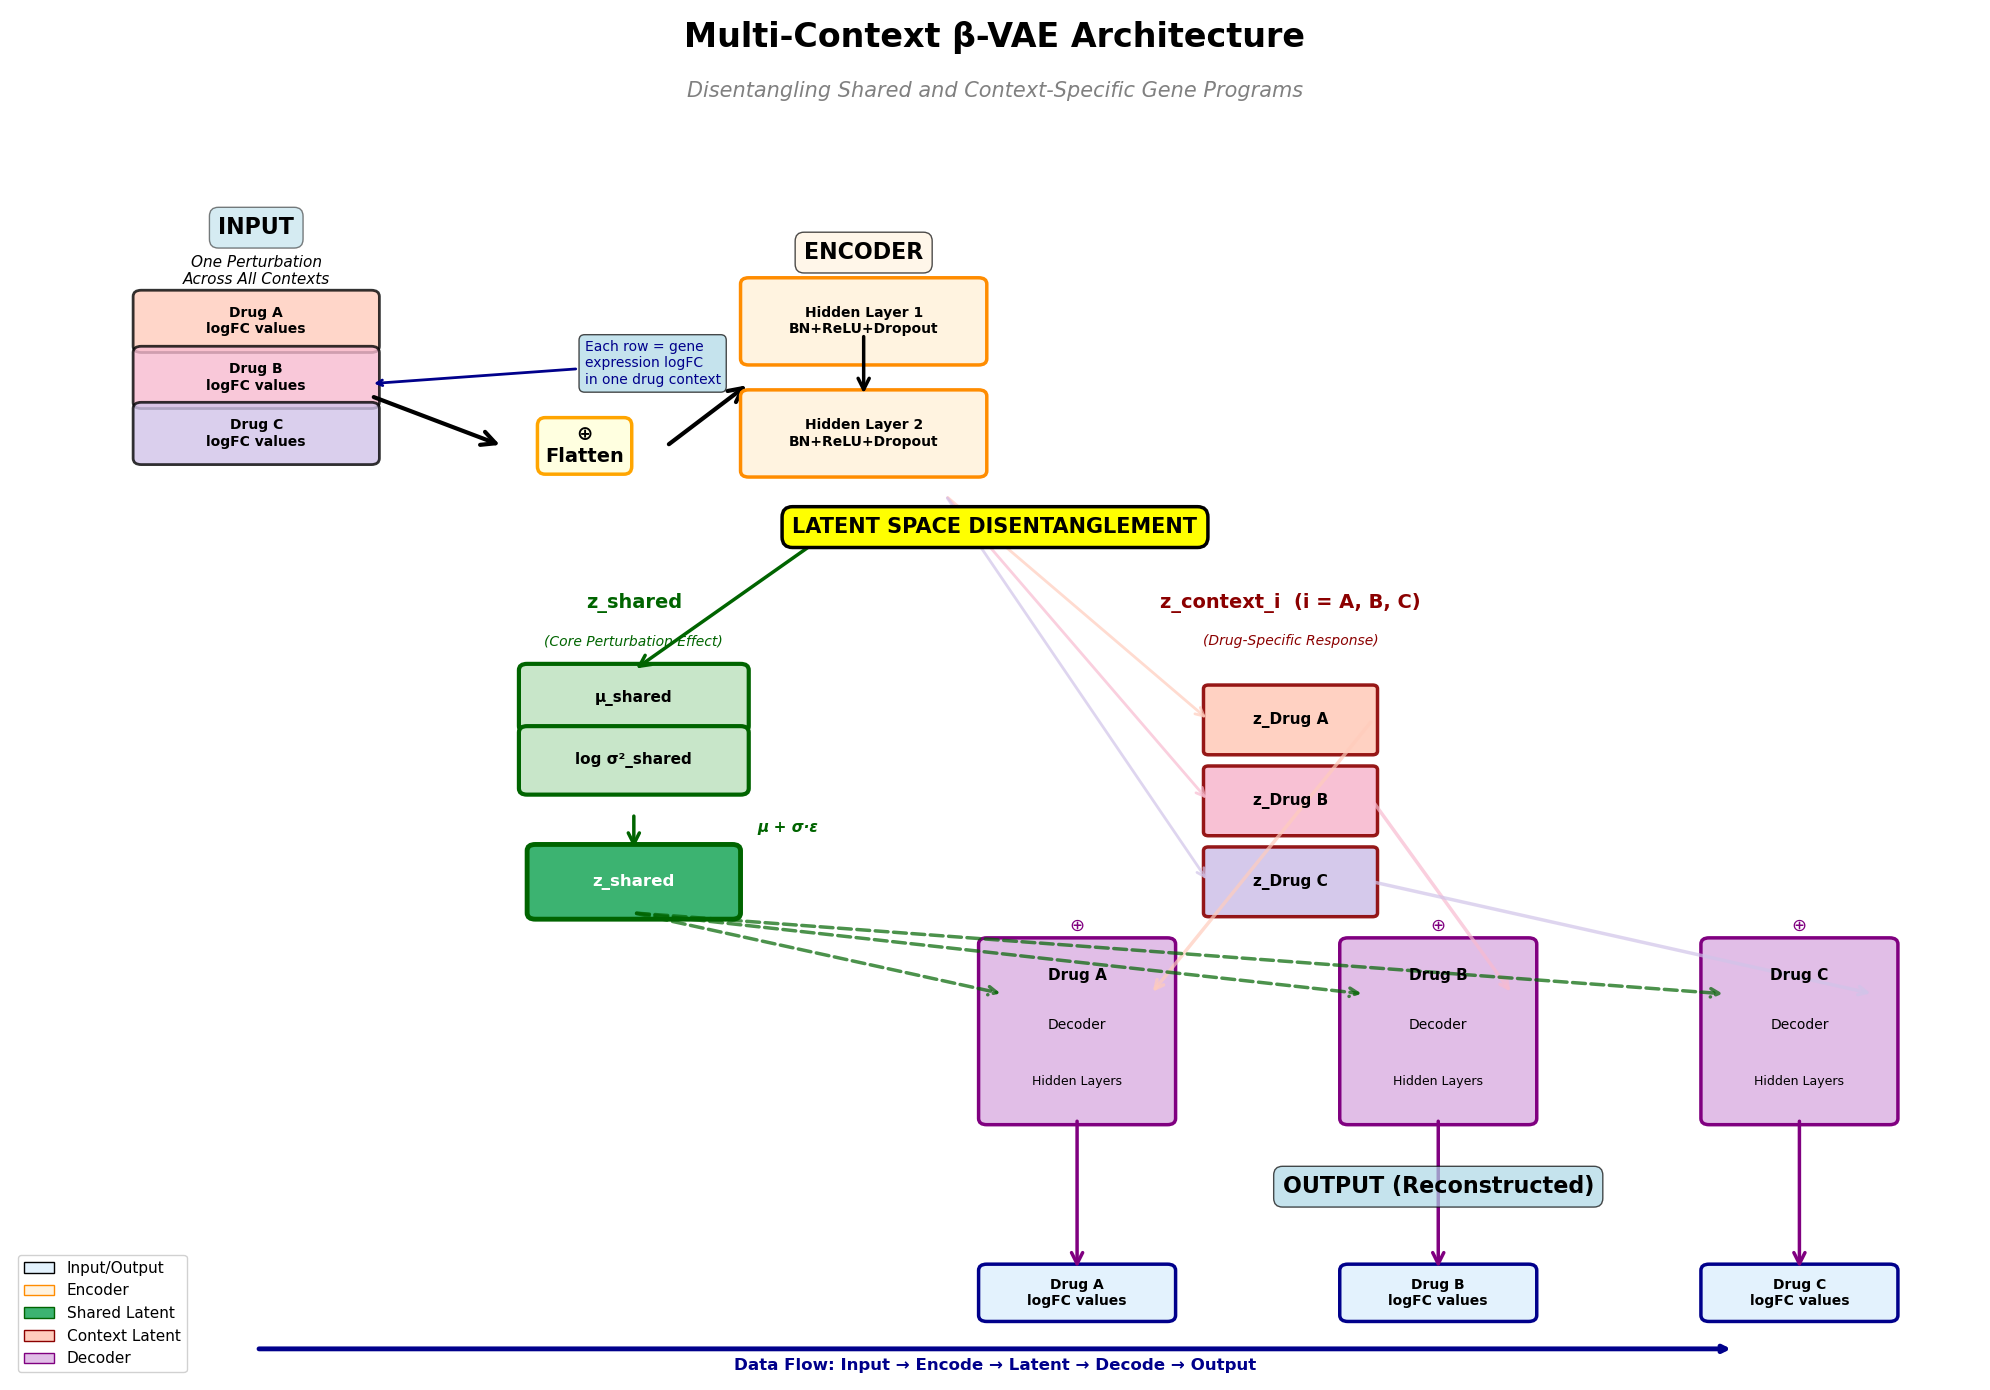

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
):
    """
    Visualize the Multi-Context β-VAE architecture.
    
    Key innovation: Each input is one perturbation across ALL drug contexts
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder = '#FFF3E0'
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = ['Drug A', 'Drug B', 'Drug C']
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=24, fontweight='bold')
    ax.text(6, 10.3, 'Disentangling Shared and Context-Specific Gene Programs', 
            ha='center', fontsize=15, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.5
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=11, style='italic')
    
    # Draw stacked contexts
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.45
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.7, y_pos - 0.2), 1.4, 0.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=2,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\nlogFC values', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Input annotation
    ax.annotate('Each row = gene\nexpression logFC\nin one drug context', 
                xy=(input_x + 0.7, input_y_start - 0.5), 
                xytext=(input_x + 2.0, input_y_start - 0.5),
                fontsize=10, color='darkblue',
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=2),
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    # ============================================================
    # CONCATENATION
    # ============================================================
    
    concat_x = 3.5
    concat_y = 7.5
    
    ax.text(concat_x, concat_y, '⊕\nFlatten', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2.5))
    
    # Arrow to concatenation
    arrow = FancyArrowPatch(
        (input_x + 0.7, input_y_start - 0.6), (concat_x - 0.5, concat_y),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # ============================================================
    # ENCODER
    # ============================================================
    
    encoder_x = 5.2
    encoder_y_start = 8.5
    
    ax.text(encoder_x, encoder_y_start + 0.5, 'ENCODER', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color_encoder, alpha=0.7))
    
    # Arrow to encoder
    arrow = FancyArrowPatch(
        (concat_x + 0.5, concat_y), (encoder_x - 0.7, encoder_y_start - 0.5),
        arrowstyle='->', mutation_scale=25, linewidth=3, color='black'
    )
    ax.add_patch(arrow)
    
    # Hidden layers (simplified - just show the concept)
    y_offset = encoder_y_start
    for i in range(2):
        box = FancyBboxPatch(
            (encoder_x - 0.7, y_offset - 0.3), 1.4, 0.6,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder, 
            edgecolor='darkorange',
            linewidth=2.5
        )
        ax.add_patch(box)
        ax.text(encoder_x, y_offset, f'Hidden Layer {i+1}\nBN+ReLU+Dropout', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        if i > 0:
            arrow = FancyArrowPatch(
                (encoder_x, y_offset + 0.8), (encoder_x, y_offset + 0.3),
                arrowstyle='->', mutation_scale=20, linewidth=2.5, color='black'
            )
            ax.add_patch(arrow)
        
        y_offset -= 0.9
    
    encoder_y_end = y_offset + 0.3
    
    # ============================================================
    # LATENT SPACE (The key innovation!)
    # ============================================================
    
    latent_y = 5.0
    
    # Central split indicator
    ax.text(6, latent_y + 1.8, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                     edgecolor='black', linewidth=2.5))
    
    # Shared latent (LEFT)
    shared_x = 3.8
    
    ax.text(shared_x, latent_y + 1.2, 'z_shared', 
            ha='center', fontsize=14, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.9, '(Core Perturbation Effect)', 
            ha='center', fontsize=10, style='italic', color='darkgreen')
    
    # μ and log σ² for shared
    mu_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y + 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(mu_box)
    ax.text(shared_x, latent_y + 0.475, 'μ_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    logvar_box = FancyBboxPatch(
        (shared_x - 0.65, latent_y - 0.25), 1.3, 0.45,
        boxstyle="round,pad=0.05", 
        facecolor=color_shared, 
        edgecolor='darkgreen',
        linewidth=3
    )
    ax.add_patch(logvar_box)
    ax.text(shared_x, latent_y - 0.025, 'log σ²_shared', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Arrow from encoder
    arrow = FancyArrowPatch(
        (encoder_x, encoder_y_end), (shared_x, latent_y + 0.7),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # Reparameterization for shared
    z_shared_y = latent_y - 1.0
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.6, z_shared_y - 0.25), 1.2, 0.5,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3.5
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, z_shared_y, 'z_shared', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Reparameterization arrow
    arrow = FancyArrowPatch(
        (shared_x, latent_y - 0.45), (shared_x, z_shared_y + 0.25),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    ax.text(shared_x + 0.75, (latent_y + z_shared_y) / 2 - 0.1, 'μ + σ·ε', 
            fontsize=11, style='italic', color='darkgreen', fontweight='bold')
    
    # Context-specific latents (RIGHT, vertical stack)
    context_x = 7.8
    
    ax.text(context_x, latent_y + 1.2, 
            'z_context_i  (i = A, B, C)', 
            ha='center', fontsize=14, fontweight='bold', color='darkred')
    ax.text(context_x, latent_y + 0.9, 
            '(Drug-Specific Response)', 
            ha='center', fontsize=10, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_y = latent_y + 0.3 - i * 0.65
        
        # Box for this context
        ctx_box = FancyBboxPatch(
            (context_x - 0.5, ctx_y - 0.25), 1.0, 0.5,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(context_x, ctx_y, f'z_{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        
        # Arrow from encoder
        arrow = FancyArrowPatch(
            (encoder_x + 0.5, encoder_y_end + 0.1), (context_x - 0.5, ctx_y),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODER (Multiple, one per context)
    # ============================================================
    
    decoder_y_start = 2.5
    decoder_x_start = 6.5
    decoder_spacing = 2.2
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Decoder box
        dec_box = FancyBboxPatch(
            (dec_x - 0.55, decoder_y_start - 0.4), 1.1, 1.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2.5
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.75, f'{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.35, 'Decoder', 
                ha='center', va='center', fontsize=10)
        ax.text(dec_x, decoder_y_start - 0.1, 'Hidden Layers', 
                ha='center', va='center', fontsize=9)
        
        # Input to decoder: [z_shared, z_context_i]
        ctx_latent_y = latent_y + 0.3 - i * 0.65
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, z_shared_y - 0.25), (dec_x - 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (context_x + 0.5, ctx_latent_y), (dec_x + 0.45, decoder_y_start + 0.6),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 1.15, '⊕', 
                ha='center', va='center', fontsize=13, color='purple')
    
    # ============================================================
    # OUTPUT (Reconstructed contexts)
    # ============================================================
    
    output_y_start = 0.7
    
    ax.text(decoder_x_start + decoder_spacing, output_y_start + 0.8, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box
        out_box = FancyBboxPatch(
            (out_x - 0.55, output_y_start - 0.18), 1.1, 0.36,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2.5
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\nlogFC values', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.4), (out_x, output_y_start + 0.18),
            arrowstyle='->', mutation_scale=20, linewidth=2.5, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder, edgecolor='darkorange', label='Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=11, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.25), xytext=(1.5, 0.25),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='darkblue'))
    ax.text(6, 0.08, 'Data Flow: Input → Encode → Latent → Decode → Output', 
            ha='center', fontsize=12, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_architecture(
    n_contexts=3,
    figsize=(20, 14)
)

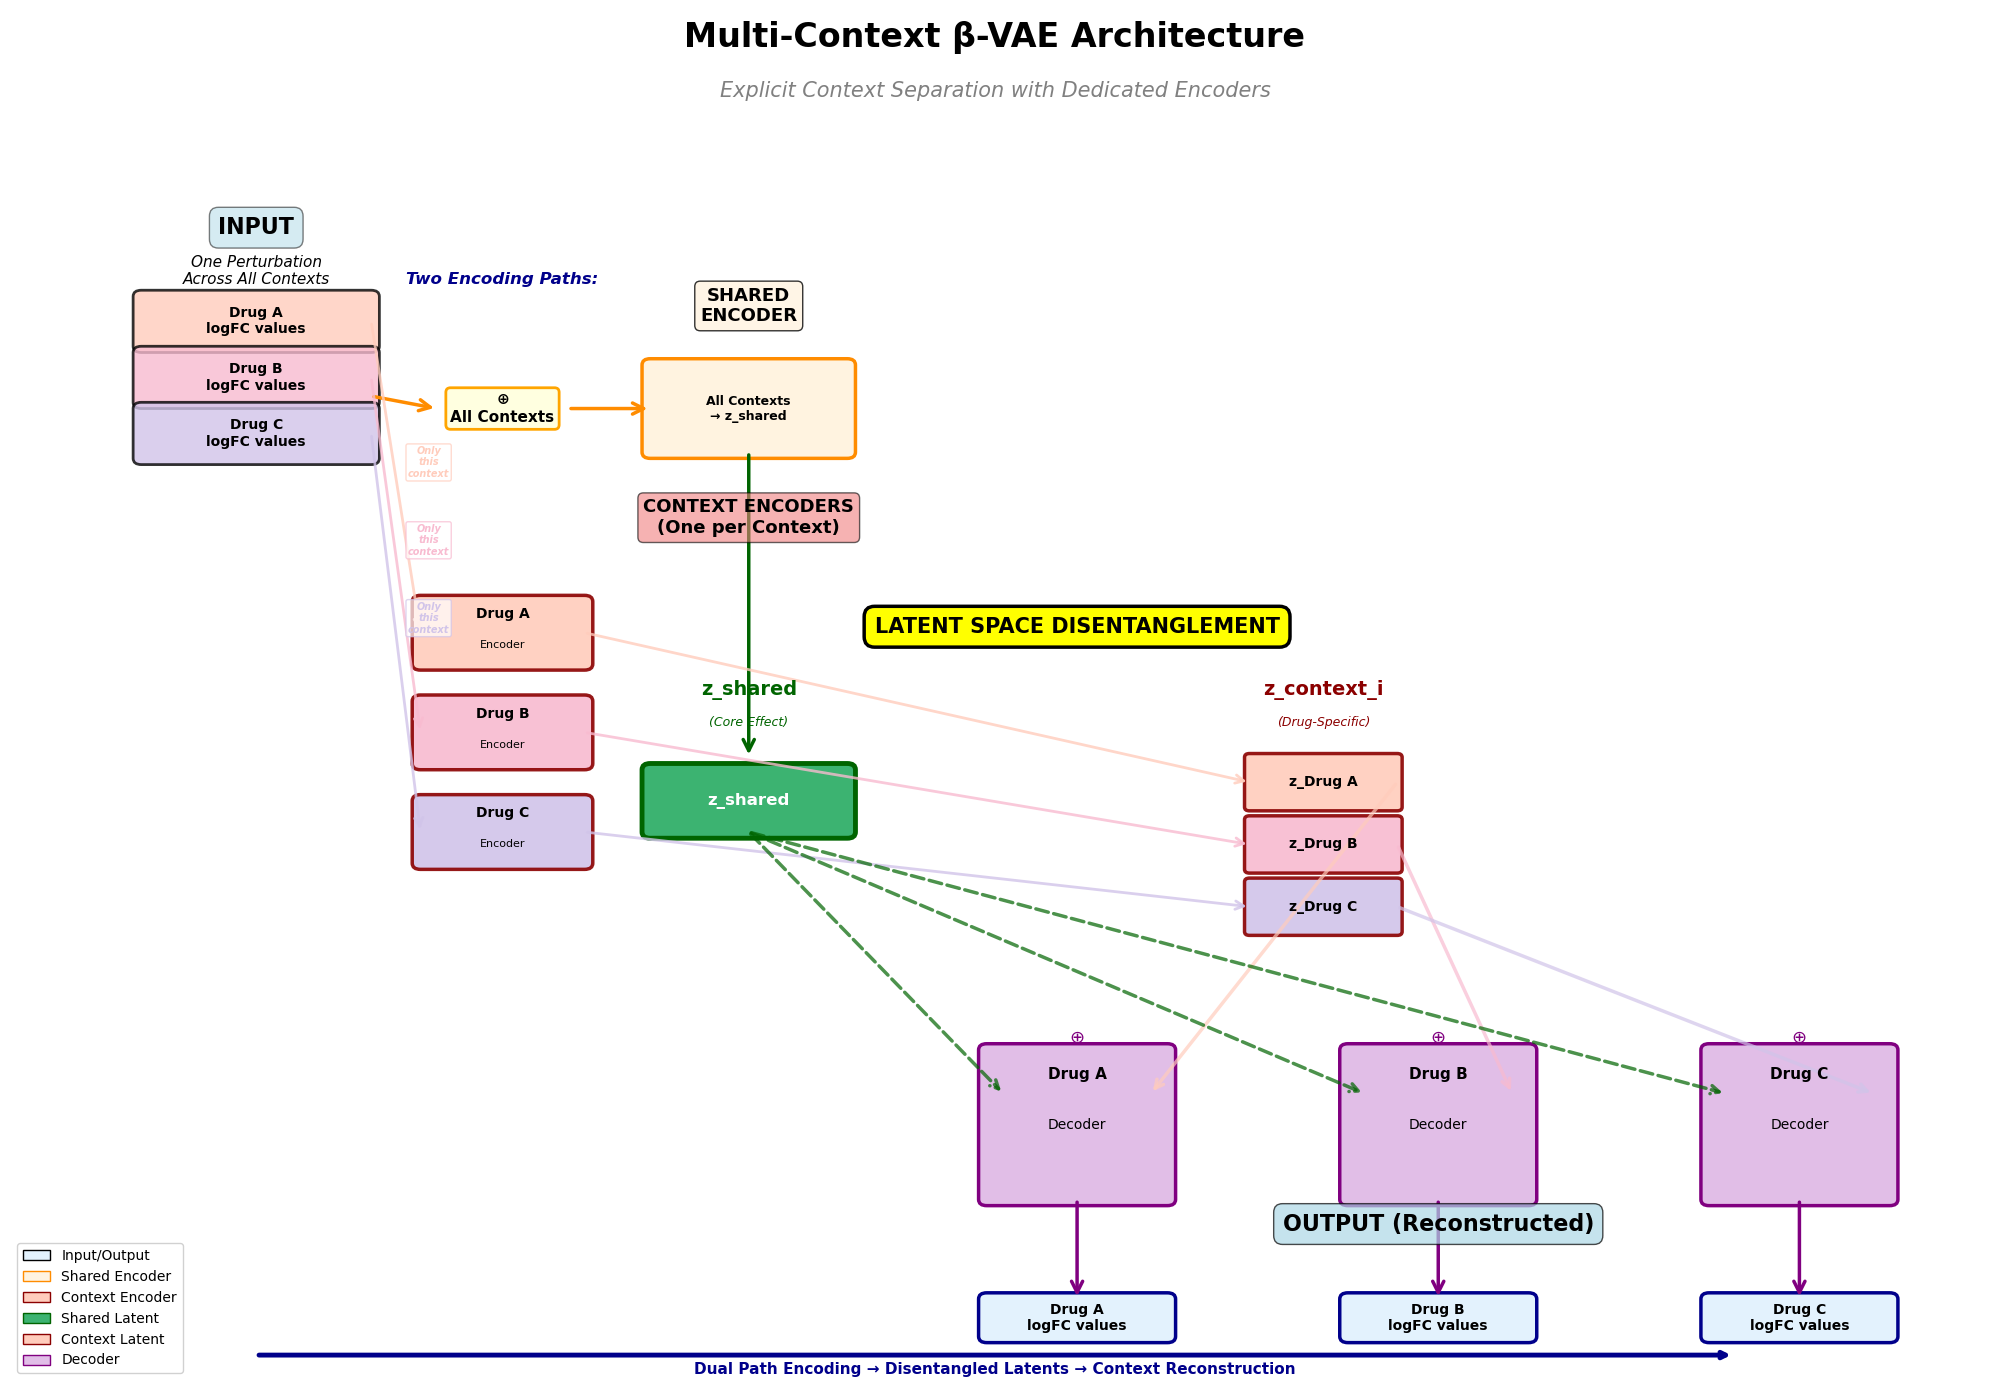

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, Wedge
import numpy as np

def plot_multicontext_beta_vae_explicit_architecture(
    n_contexts=3,
    figsize=(20, 14)
):
    """
    Visualize the Multi-Context β-VAE architecture with EXPLICIT context separation.
    
    Key: Separate encoders for each context ensure z_context_i genuinely represents context i.
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.axis('off')
    
    # Colors
    color_input = '#E3F2FD'
    color_encoder_shared = '#FFF3E0'
    color_encoder_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9']
    color_shared = '#C8E6C9'
    color_context = ['#FFCCBC', '#F8BBD0', '#D1C4E9']
    color_decoder = '#E1BEE7'
    color_output = '#E3F2FD'
    
    context_names = ['Drug A', 'Drug B', 'Drug C']
    
    # ============================================================
    # TITLE
    # ============================================================
    
    ax.text(6, 10.7, 'Multi-Context β-VAE Architecture', 
            ha='center', fontsize=24, fontweight='bold')
    ax.text(6, 10.3, 'Explicit Context Separation with Dedicated Encoders', 
            ha='center', fontsize=15, style='italic', color='gray')
    
    # ============================================================
    # INPUT: One perturbation across all contexts
    # ============================================================
    
    input_y_start = 8.5
    input_x = 1.5
    
    ax.text(input_x, input_y_start + 0.7, 'INPUT', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.5))
    
    ax.text(input_x, input_y_start + 0.3, 'One Perturbation\nAcross All Contexts', 
            ha='center', fontsize=11, style='italic')
    
    # Draw stacked contexts
    for i, ctx_name in enumerate(context_names):
        y_pos = input_y_start - i * 0.45
        
        # Box for context
        box = FancyBboxPatch(
            (input_x - 0.7, y_pos - 0.2), 1.4, 0.4,
            boxstyle="round,pad=0.05", 
            facecolor=color_context[i], 
            edgecolor='black',
            linewidth=2,
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Label
        ax.text(input_x, y_pos, f'{ctx_name}\nlogFC values', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # ============================================================
    # DUAL ENCODING PATHS
    # ============================================================
    
    # Path indicator
    ax.text(3.0, 8.8, 'Two Encoding Paths:', 
            ha='center', fontsize=12, fontweight='bold', style='italic',
            color='darkblue')
    
    # ============================================================
    # PATH 1: SHARED ENCODER (takes all contexts)
    # ============================================================
    
    shared_path_y = 7.8
    shared_encoder_x = 3.0
    
    # Concatenation for shared
    ax.text(shared_encoder_x, shared_path_y, '⊕\nAll Contexts', 
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', 
                     edgecolor='orange', linewidth=2))
    
    # Arrow from input to shared concat
    arrow = FancyArrowPatch(
        (input_x + 0.7, input_y_start - 0.6), (shared_encoder_x - 0.4, shared_path_y),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkorange'
    )
    ax.add_patch(arrow)
    
    # Shared encoder
    encoder_shared_x = 4.5
    
    ax.text(encoder_shared_x, shared_path_y + 0.7, 'SHARED\nENCODER', 
            ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color_encoder_shared, alpha=0.8))
    
    box = FancyBboxPatch(
        (encoder_shared_x - 0.6, shared_path_y - 0.35), 1.2, 0.7,
        boxstyle="round,pad=0.05", 
        facecolor=color_encoder_shared, 
        edgecolor='darkorange',
        linewidth=2.5
    )
    ax.add_patch(box)
    ax.text(encoder_shared_x, shared_path_y, 'All Contexts\n→ z_shared', 
            ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Arrow to shared encoder
    arrow = FancyArrowPatch(
        (shared_encoder_x + 0.4, shared_path_y), (encoder_shared_x - 0.6, shared_path_y),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkorange'
    )
    ax.add_patch(arrow)
    
    # ============================================================
    # PATH 2: CONTEXT-SPECIFIC ENCODERS (separate for each context)
    # ============================================================
    
    context_encoder_x_start = 3.0
    context_encoder_y_start = 6.0
    
    ax.text(context_encoder_x_start + 1.5, context_encoder_y_start + 0.8, 
            'CONTEXT ENCODERS\n(One per Context)', 
            ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.6))
    
    for i, ctx_name in enumerate(context_names):
        enc_y = context_encoder_y_start - i * 0.8
        input_y = input_y_start - i * 0.45
        
        # Context encoder box
        enc_box = FancyBboxPatch(
            (context_encoder_x_start - 0.5, enc_y - 0.25), 1.0, 0.5,
            boxstyle="round,pad=0.05", 
            facecolor=color_encoder_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(enc_box)
        
        ax.text(context_encoder_x_start, enc_y + 0.15, f'{ctx_name}', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(context_encoder_x_start, enc_y - 0.1, 'Encoder', 
                ha='center', va='center', fontsize=8)
        
        # Arrow from specific context input to its encoder
        arrow = FancyArrowPatch(
            (input_x + 0.7, input_y), (context_encoder_x_start - 0.5, enc_y),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.8
        )
        ax.add_patch(arrow)
        
        # Label on arrow
        ax.text((input_x + context_encoder_x_start) / 2 + 0.3, (input_y + enc_y) / 2, 
                'Only\nthis\ncontext', 
                ha='center', fontsize=7, style='italic', 
                color=color_context[i], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=color_context[i]))
    
    # ============================================================
    # LATENT SPACE
    # ============================================================
    
    latent_y = 4.5
    
    # Central split indicator
    ax.text(6.5, latent_y + 1.5, 'LATENT SPACE DISENTANGLEMENT', 
            ha='center', fontsize=15, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                     edgecolor='black', linewidth=2.5))
    
    # Shared latent (from shared encoder)
    shared_x = 4.5
    
    ax.text(shared_x, latent_y + 1.0, 'z_shared', 
            ha='center', fontsize=14, fontweight='bold', color='darkgreen')
    ax.text(shared_x, latent_y + 0.75, '(Core Effect)', 
            ha='center', fontsize=9, style='italic', color='darkgreen')
    
    # Arrow from shared encoder to z_shared
    arrow = FancyArrowPatch(
        (encoder_shared_x, shared_path_y - 0.35), (shared_x, latent_y + 0.5),
        arrowstyle='->', mutation_scale=20, linewidth=2.5, color='darkgreen'
    )
    ax.add_patch(arrow)
    
    # z_shared box (simplified - just one box)
    z_shared_box = FancyBboxPatch(
        (shared_x - 0.6, latent_y - 0.1), 1.2, 0.5,
        boxstyle="round,pad=0.05", 
        facecolor='mediumseagreen', 
        edgecolor='darkgreen',
        linewidth=3.5
    )
    ax.add_patch(z_shared_box)
    ax.text(shared_x, latent_y + 0.15, 'z_shared', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Context-specific latents (from context encoders)
    context_latent_x = 8.0
    
    ax.text(context_latent_x, latent_y + 1.0, 
            'z_context_i', 
            ha='center', fontsize=14, fontweight='bold', color='darkred')
    ax.text(context_latent_x, latent_y + 0.75, 
            '(Drug-Specific)', 
            ha='center', fontsize=9, style='italic', color='darkred')
    
    for i, ctx_name in enumerate(context_names):
        ctx_y = latent_y + 0.3 - i * 0.5
        enc_y = context_encoder_y_start - i * 0.8
        
        # z_context box
        ctx_box = FancyBboxPatch(
            (context_latent_x - 0.45, ctx_y - 0.2), 0.9, 0.4,
            boxstyle="round,pad=0.03", 
            facecolor=color_context[i], 
            edgecolor='darkred',
            linewidth=2.5,
            alpha=0.9
        )
        ax.add_patch(ctx_box)
        ax.text(context_latent_x, ctx_y, f'z_{ctx_name}', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from context encoder to z_context_i
        arrow = FancyArrowPatch(
            (context_encoder_x_start + 0.5, enc_y), (context_latent_x - 0.45, ctx_y),
            arrowstyle='->', mutation_scale=15, linewidth=2, 
            color=color_context[i], alpha=0.8
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # DECODERS
    # ============================================================
    
    decoder_y_start = 1.8
    decoder_x_start = 6.5
    decoder_spacing = 2.2
    
    for i, ctx_name in enumerate(context_names):
        dec_x = decoder_x_start + i * decoder_spacing
        ctx_latent_y = latent_y + 0.3 - i * 0.5
        
        # Decoder box
        dec_box = FancyBboxPatch(
            (dec_x - 0.55, decoder_y_start - 0.35), 1.1, 1.2,
            boxstyle="round,pad=0.05", 
            facecolor=color_decoder, 
            edgecolor='purple',
            linewidth=2.5
        )
        ax.add_patch(dec_box)
        
        # Decoder label
        ax.text(dec_x, decoder_y_start + 0.65, f'{ctx_name}', 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(dec_x, decoder_y_start + 0.25, 'Decoder', 
                ha='center', va='center', fontsize=10)
        
        # Arrow from z_shared
        arrow = FancyArrowPatch(
            (shared_x, latent_y - 0.1), (dec_x - 0.45, decoder_y_start + 0.5),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color='darkgreen', linestyle='--', alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Arrow from z_context_i
        arrow = FancyArrowPatch(
            (context_latent_x + 0.45, ctx_latent_y), (dec_x + 0.45, decoder_y_start + 0.5),
            arrowstyle='->', mutation_scale=15, linewidth=2.5, 
            color=color_context[i], alpha=0.7
        )
        ax.add_patch(arrow)
        
        # Concatenation indicator
        ax.text(dec_x, decoder_y_start + 0.95, '⊕', 
                ha='center', va='center', fontsize=13, color='purple')
    
    # ============================================================
    # OUTPUT
    # ============================================================
    
    output_y_start = 0.5
    
    ax.text(decoder_x_start + decoder_spacing, output_y_start + 0.7, 
            'OUTPUT (Reconstructed)', 
            ha='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
    
    for i, ctx_name in enumerate(context_names):
        out_x = decoder_x_start + i * decoder_spacing
        dec_x = decoder_x_start + i * decoder_spacing
        
        # Output box
        out_box = FancyBboxPatch(
            (out_x - 0.55, output_y_start - 0.15), 1.1, 0.3,
            boxstyle="round,pad=0.05", 
            facecolor=color_output, 
            edgecolor='darkblue',
            linewidth=2.5
        )
        ax.add_patch(out_box)
        
        ax.text(out_x, output_y_start, f'{ctx_name}\nlogFC values', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Arrow from decoder
        arrow = FancyArrowPatch(
            (dec_x, decoder_y_start - 0.35), (out_x, output_y_start + 0.15),
            arrowstyle='->', mutation_scale=20, linewidth=2.5, color='purple'
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # LEGEND
    # ============================================================
    
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input/Output'),
        mpatches.Patch(facecolor=color_encoder_shared, edgecolor='darkorange', label='Shared Encoder'),
        mpatches.Patch(facecolor=color_encoder_context[0], edgecolor='darkred', label='Context Encoder'),
        mpatches.Patch(facecolor='mediumseagreen', edgecolor='darkgreen', label='Shared Latent'),
        mpatches.Patch(facecolor=color_context[0], edgecolor='darkred', label='Context Latent'),
        mpatches.Patch(facecolor=color_decoder, edgecolor='purple', label='Decoder'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)
    
    # ============================================================
    # WORKFLOW ARROWS
    # ============================================================
    
    # Big workflow arrow at bottom
    ax.annotate('', xy=(10.5, 0.2), xytext=(1.5, 0.2),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='darkblue'))
    ax.text(6, 0.05, 'Dual Path Encoding → Disentangled Latents → Context Reconstruction', 
            ha='center', fontsize=11, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig('multicontext_beta_vae_explicit_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ============================================================
# Usage
# ============================================================

plot_multicontext_beta_vae_explicit_architecture(
    n_contexts=3,
    figsize=(20, 14)
)